###TIME SERIES FORECAST MODELLING

###PART1: DATA READING AND EDA

In [ ]:
# Part 1 - reading the data and checking the German electricity load

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose

warnings.filterwarnings("ignore")

In [ ]:
# I have kept the csv file in the Colab content folder

data = "https://data.open-power-system-data.org/time_series/2020-10-06/time_series_60min_singleindex.csv"

csv_name=data

table = pd.read_csv(csv_name)

table.head()

,utc_timestamp,cet_cest_timestamp,AT_load_actual_entsoe_transparency,AT_load_forecast_entsoe_transparency,AT_price_day_ahead,AT_solar_generation_actual,AT_wind_onshore_generation_actual,BE_load_actual_entsoe_transparency,BE_load_forecast_entsoe_transparency,BE_solar_generation_actual,...,SI_load_actual_entsoe_transparency,SI_load_forecast_entsoe_transparency,SI_solar_generation_actual,SI_wind_onshore_generation_actual,SK_load_actual_entsoe_transparency,SK_load_forecast_entsoe_transparency,SK_solar_generation_actual,SK_wind_onshore_generation_actual,UA_load_actual_entsoe_transparency,UA_load_forecast_entsoe_transparency
0,2014-12-31T23:00:00Z,2015-01-01T00:00:00+0100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2015-01-01T00:00:00Z,2015-01-01T01:00:00+0100,5946.0,6701.0,35.0,NaN,69.0,9484.0,9897.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2015-01-01T01:00:00Z,2015-01-01T02:00:00+0100,5726.0,6593.0,45.0,NaN,64.0,9152.0,9521.0,NaN,...,1045.47,816.0,NaN,1.17,2728.0,2860.0,3.8,NaN,NaN,NaN
3,2015-01-01T02:00:00Z,2015-01-01T03:00:00+0100,5347.0,6482.0,41.0,NaN,65.0,8799.0,9135.0,NaN,...,1004.79,805.0,NaN,1.04,2626.0,2810.0,3.8,NaN,NaN,NaN
4,2015-01-01T03:00:00Z,2015-01-01T04:00:00+0100,5249.0,6454.0,38.0,NaN,64.0,8567.0,8909.0,NaN,...,983.79,803.0,NaN,1.61,2618.0,2780.0,3.8,NaN,NaN,NaN


In [ ]:
# Taking only the two columns needed for this work

germany = table[
    [
        "utc_timestamp",
        "DE_load_actual_entsoe_transparency"
    ]
].copy()

germany.columns = [
    "time",
    "load"
]

germany.head()

,time,load
0,2014-12-31T23:00:00Z,NaN
1,2015-01-01T00:00:00Z,41151.0
2,2015-01-01T01:00:00Z,40135.0
3,2015-01-01T02:00:00Z,39106.0
4,2015-01-01T03:00:00Z,38765.0


In [ ]:
# Making the time column usable as a time index

germany["time"] = pd.to_datetime(
    germany["time"],
    utc=True
)

germany = germany.set_index("time")
germany = germany.sort_index()

print("First date in file:", germany.index.min())
print("Last date in file:", germany.index.max())

First date in file: 2014-12-31 23:00:00+00:00
Last date in file: 2020-09-30 23:00:00+00:00


In [ ]:
# Keeping the assignment period only

germany = germany.loc[
    "2015-01-01":"2020-09-30"
].copy()

print("First date used:", germany.index.min())
print("Last date used:", germany.index.max())
print("Number of hourly rows:", len(germany))

First date used: 2015-01-01 00:00:00+00:00
Last date used: 2020-09-30 23:00:00+00:00
Number of hourly rows: 50400


In [ ]:
# Checking missing values before doing any modelling

print("Missing load values before cleaning:")
print(germany["load"].isna().sum())

Missing load values before cleaning:
0


In [ ]:
# Filling missing values if any are present

germany["load"] = germany["load"].interpolate()

print("Missing load values after cleaning:")
print(germany["load"].isna().sum())

Missing load values after cleaning:
0


In [ ]:
# Making the hourly, daily and weekly series

hourly_load = germany["load"]

daily_load = hourly_load.resample("D").mean()

weekly_load = hourly_load.resample("W").mean()

print("Hourly length:", len(hourly_load))
print("Daily length:", len(daily_load))
print("Weekly length:", len(weekly_load))

Hourly length: 50400
Daily length: 2100
Weekly length: 301


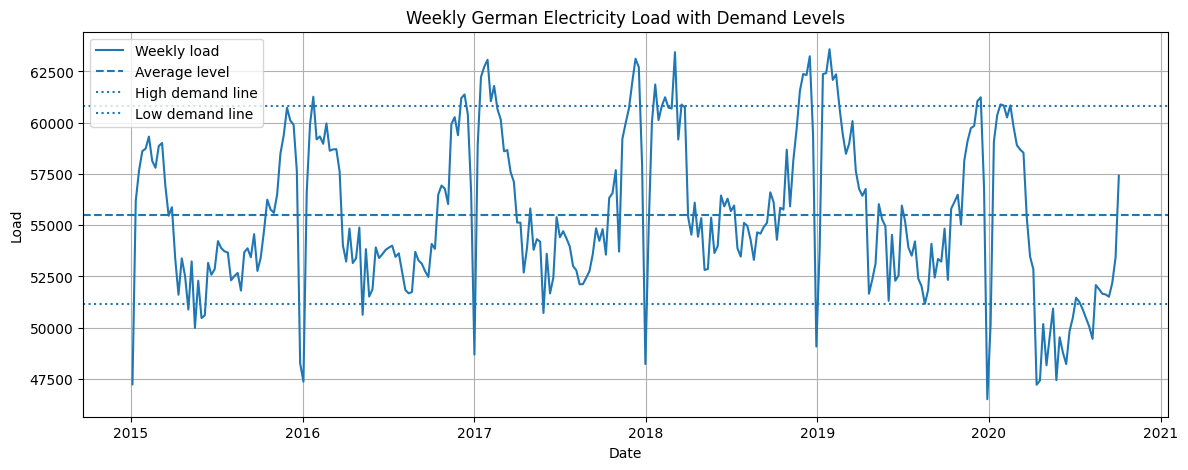

In [ ]:
# This plot gives a quick idea of normal, high and low weekly demand

normal_week = weekly_load.mean()
high_week = weekly_load.quantile(0.90)
low_week = weekly_load.quantile(0.10)

plt.figure(figsize=(14, 5))

plt.plot(
    weekly_load.index,
    weekly_load,
    label="Weekly load"
)

plt.axhline(
    normal_week,
    linestyle="--",
    label="Average level"
)

plt.axhline(
    high_week,
    linestyle=":",
    label="High demand line"
)

plt.axhline(
    low_week,
    linestyle=":",
    label="Low demand line"
)

plt.title("Weekly German Electricity Load with Demand Levels")
plt.xlabel("Date")
plt.ylabel("Load")
plt.legend()
plt.grid(True)
plt.show()

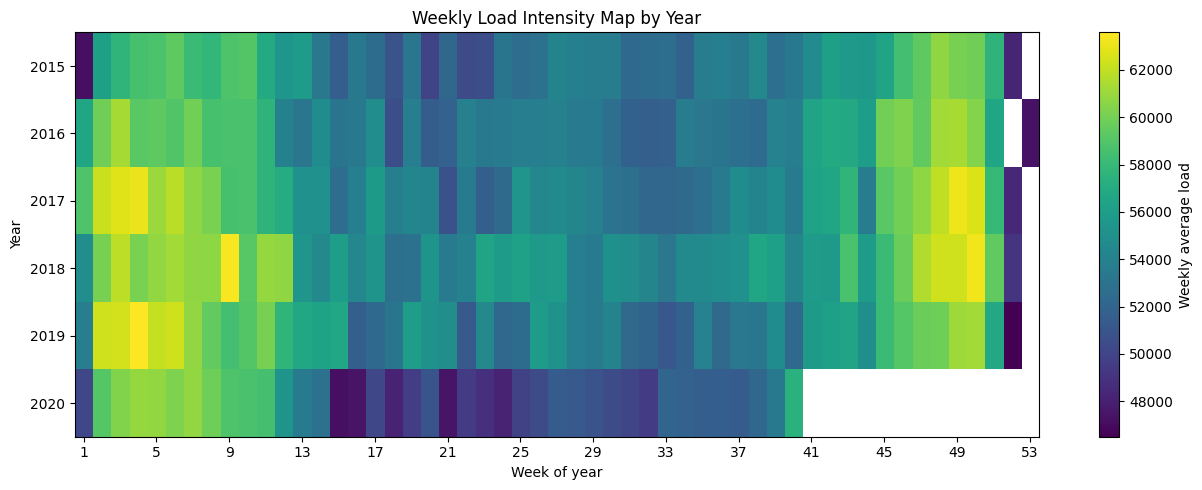

In [ ]:
year_check = weekly_load.to_frame(name="load")

year_check["year"] = year_check.index.year
year_check["week"] = year_check.index.isocalendar().week.astype(int)

year_week_matrix_v4 = year_check.pivot_table(
    index="year",
    columns="week",
    values="load",
    aggfunc="mean"
)

fig, ax = plt.subplots(figsize=(13, 5))

heatmap_v4 = ax.imshow(
    year_week_matrix_v4.values,
    aspect="auto"
)

ax.set_title("Weekly Load Intensity Map by Year")
ax.set_xlabel("Week of year")
ax.set_ylabel("Year")

ax.set_yticks(np.arange(len(year_week_matrix_v4.index)))
ax.set_yticklabels(year_week_matrix_v4.index)

week_tick_positions_v4 = np.arange(0, len(year_week_matrix_v4.columns), 4)
ax.set_xticks(week_tick_positions_v4)
ax.set_xticklabels(
    year_week_matrix_v4.columns[week_tick_positions_v4],
    rotation=0
)

cbar = plt.colorbar(heatmap_v4, ax=ax)
cbar.set_label("Weekly average load")

plt.tight_layout()
plt.show()


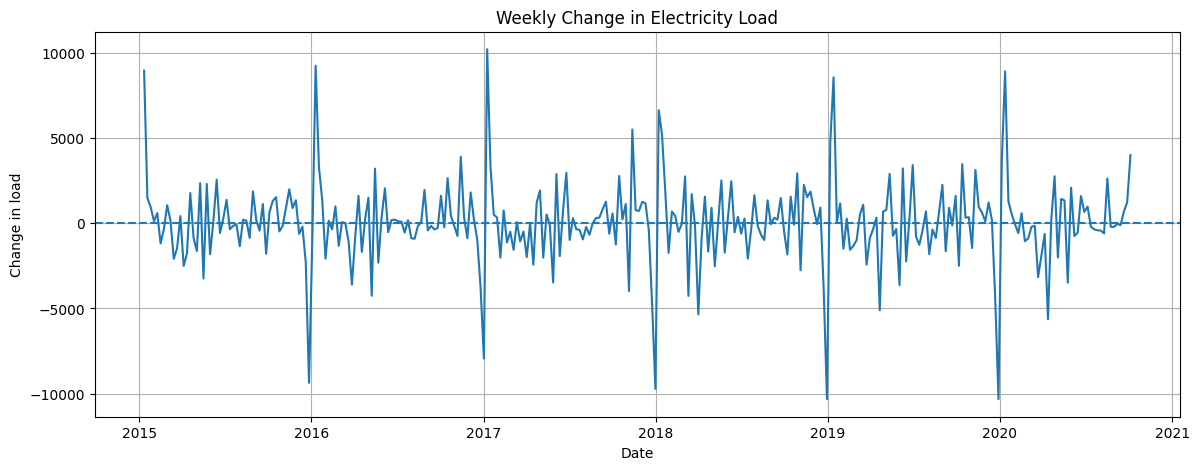

In [ ]:
# This shows how much demand changes from one week to the next

week_change = weekly_load.diff()

plt.figure(figsize=(14, 5))

plt.plot(
    week_change.index,
    week_change
)

plt.axhline(
    0,
    linestyle="--"
)

plt.title("Weekly Change in Electricity Load")
plt.xlabel("Date")
plt.ylabel("Change in load")
plt.grid(True)
plt.show()

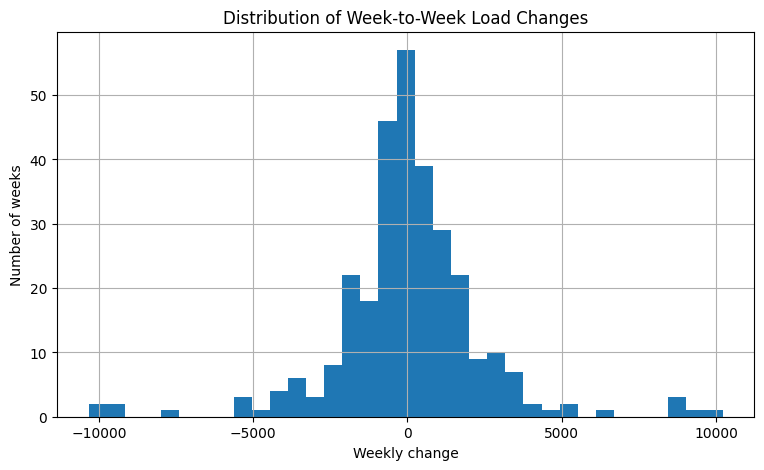

In [ ]:
# Histogram of weekly changes

plt.figure(figsize=(9, 5))

plt.hist(
    week_change.dropna(),
    bins=35
)

plt.title("Distribution of Week-to-Week Load Changes")
plt.xlabel("Weekly change")
plt.ylabel("Number of weeks")
plt.grid(True)
plt.show()

In [ ]:
# Average and median load for each week of the year

week_pattern = (
    year_check
    .groupby("week")["load"]
    .agg(["mean", "median", "std"])
    .reset_index()
)

week_pattern.head()

,week,mean,median,std
0,1,53596.295883,54332.154762,4270.567988
1,2,59973.419643,59982.979167,2279.517766
2,3,61054.624008,61567.898810,1861.151125
3,4,60912.969246,60510.982143,2034.474168
4,5,60475.965278,60827.645833,1226.692376


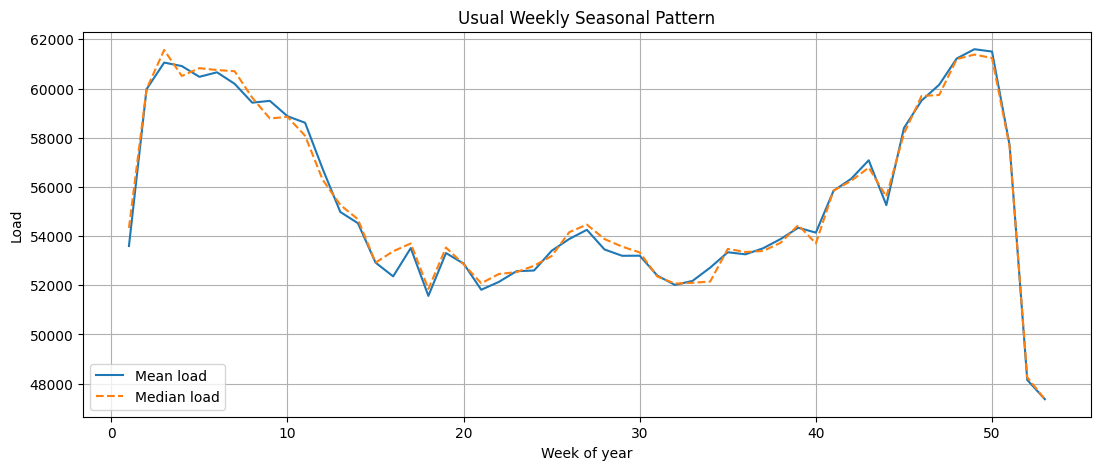

In [ ]:
plt.figure(figsize=(13, 5))

plt.plot(
    week_pattern["week"],
    week_pattern["mean"],
    label="Mean load"
)

plt.plot(
    week_pattern["week"],
    week_pattern["median"],
    linestyle="--",
    label="Median load"
)

plt.title("Usual Weekly Seasonal Pattern")
plt.xlabel("Week of year")
plt.ylabel("Load")
plt.legend()
plt.grid(True)
plt.show()

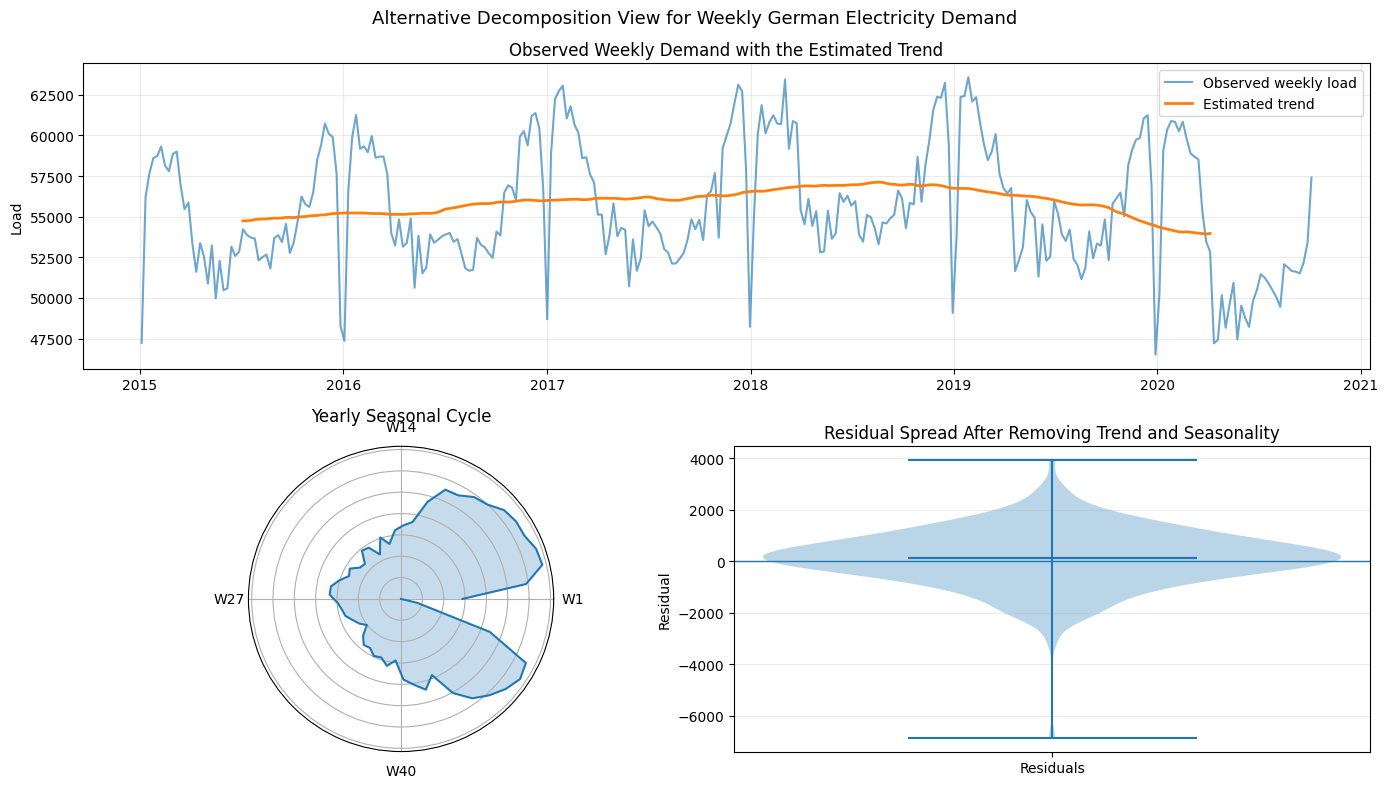

In [ ]:
load_parts = seasonal_decompose(
    weekly_load.dropna(),
    model="additive",
    period=52
)

observed_v4 = load_parts.observed.dropna()
trend_v4 = load_parts.trend.dropna()
seasonal_v4 = load_parts.seasonal.dropna()
residual_v4 = load_parts.resid.dropna()

seasonal_week_v4 = (
    seasonal_v4
    .groupby(seasonal_v4.index.isocalendar().week)
    .mean()
)

seasonal_angles_v4 = np.linspace(
    0,
    2 * np.pi,
    len(seasonal_week_v4),
    endpoint=False
)

seasonal_radius_v4 = seasonal_week_v4.values - seasonal_week_v4.values.min()

fig = plt.figure(figsize=(14, 8))

ax_main = fig.add_subplot(2, 2, (1, 2))
ax_season = fig.add_subplot(2, 2, 3, projection="polar")
ax_resid = fig.add_subplot(2, 2, 4)

ax_main.plot(
    observed_v4.index,
    observed_v4.values,
    label="Observed weekly load",
    alpha=0.65
)

ax_main.plot(
    trend_v4.index,
    trend_v4.values,
    label="Estimated trend",
    linewidth=2
)

ax_main.set_title("Observed Weekly Demand with the Estimated Trend")
ax_main.set_ylabel("Load")
ax_main.legend()
ax_main.grid(True, alpha=0.25)

ax_season.plot(
    seasonal_angles_v4,
    seasonal_radius_v4
)

ax_season.fill(
    seasonal_angles_v4,
    seasonal_radius_v4,
    alpha=0.25
)

ax_season.set_title("Yearly Seasonal Cycle", pad=18)
ax_season.set_xticks(np.linspace(0, 2 * np.pi, 4, endpoint=False))
ax_season.set_xticklabels(["W1", "W14", "W27", "W40"])
ax_season.set_yticklabels([])

ax_resid.violinplot(
    residual_v4.values,
    showmeans=True,
    showmedians=True
)

ax_resid.axhline(0, linewidth=1)
ax_resid.set_title("Residual Spread After Removing Trend and Seasonality")
ax_resid.set_ylabel("Residual")
ax_resid.set_xticks([1])
ax_resid.set_xticklabels(["Residuals"])
ax_resid.grid(True, axis="y", alpha=0.25)

fig.suptitle("Alternative Decomposition View for Weekly German Electricity Demand", fontsize=13)
plt.tight_layout()
plt.show()


In [ ]:
# Function to run ADF and KPSS tests together

def stationarity_check(values, name):

    values = values.dropna()

    adf = adfuller(
        values,
        autolag="AIC"
    )

    kpss_test = kpss(
        values,
        regression="c",
        nlags="auto"
    )

    return {
        "Series": name,
        "ADF Statistic": adf[0],
        "ADF p-value": adf[1],
        "KPSS Statistic": kpss_test[0],
        "KPSS p-value": kpss_test[1],
        "ADF Comment": "Stationary" if adf[1] < 0.05 else "Not stationary",
        "KPSS Comment": "Stationary" if kpss_test[1] > 0.05 else "Not stationary"
    }

In [ ]:
# First difference and seasonal difference

first_diff = weekly_load.diff()

season_diff = weekly_load.diff(52)

In [ ]:
# Summary of stationarity checks

test_table = pd.DataFrame(
    [
        stationarity_check(
            weekly_load,
            "Original weekly load"
        ),
        stationarity_check(
            first_diff,
            "First difference"
        ),
        stationarity_check(
            season_diff,
            "Seasonal difference"
        )
    ]
)

test_table

,Series,ADF Statistic,ADF p-value,KPSS Statistic,KPSS p-value,ADF Comment,KPSS Comment
0,Original weekly load,-4.047472,1.181350e-03,0.160374,0.10,Stationary,Stationary
1,First difference,-7.069318,4.984737e-10,0.055754,0.10,Stationary,Stationary
2,Seasonal difference,-4.295072,4.530219e-04,1.341877,0.01,Stationary,Not stationary


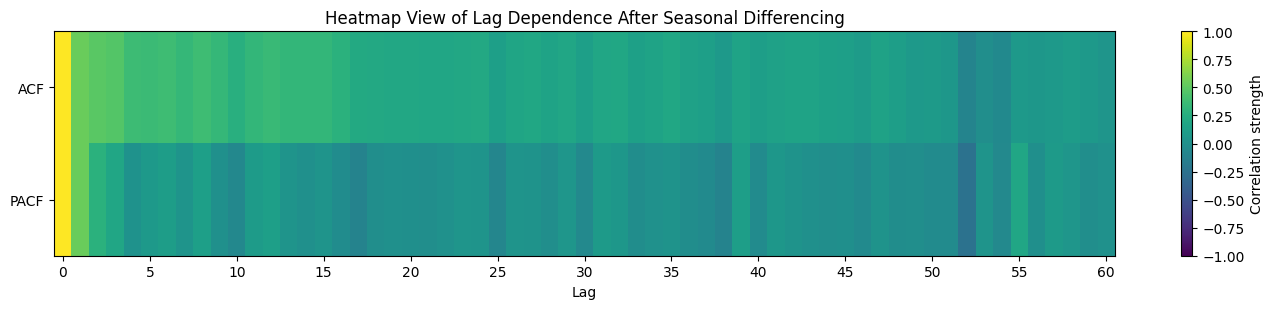

In [ ]:
from statsmodels.tsa.stattools import acf, pacf

max_lag_v4 = 60
season_diff_clean_v4 = season_diff.dropna()

acf_season_v4 = acf(season_diff_clean_v4, nlags=max_lag_v4, fft=True)
pacf_season_v4 = pacf(season_diff_clean_v4, nlags=max_lag_v4, method="ywm")

lag_matrix_v4 = pd.DataFrame(
    [acf_season_v4, pacf_season_v4],
    index=["ACF", "PACF"],
    columns=np.arange(max_lag_v4 + 1)
)

fig, ax = plt.subplots(figsize=(14, 3.2))

lag_heat_v4 = ax.imshow(
    lag_matrix_v4.values,
    aspect="auto",
    vmin=-1,
    vmax=1
)

ax.set_title("Heatmap View of Lag Dependence After Seasonal Differencing")
ax.set_xlabel("Lag")
ax.set_yticks(np.arange(len(lag_matrix_v4.index)))
ax.set_yticklabels(lag_matrix_v4.index)

lag_tick_positions_v4 = np.arange(0, max_lag_v4 + 1, 5)
ax.set_xticks(lag_tick_positions_v4)
ax.set_xticklabels(lag_tick_positions_v4)

cbar = plt.colorbar(lag_heat_v4, ax=ax)
cbar.set_label("Correlation strength")

plt.tight_layout()
plt.show()


In [ ]:
# This function is used later for all model errors

from sklearn.metrics import mean_squared_error, mean_absolute_error

def model_errors(real, forecast):

    real = np.asarray(real)
    forecast = np.asarray(forecast)

    rmse = np.sqrt(
        mean_squared_error(real, forecast)
    )

    mae = mean_absolute_error(
        real,
        forecast
    )

    mape = np.mean(
        np.abs((real - forecast) / real)
    ) * 100

    return rmse, mae, mape

In [ ]:
# Keeping one final weekly variable for the forecasting sections

weekly_series = weekly_load.copy()
print("Weekly observations:", len(weekly_series))

Weekly observations: 301


###PART2: SIMPLE BENCHMARK FORECAST MODELS

In [ ]:
# The last 104 weeks are used as the test period

last_two_years = 104

train_load = weekly_series.iloc[:-last_two_years]
test_load = weekly_series.iloc[-last_two_years:]

print("Training weeks:", len(train_load))
print("Testing weeks:", len(test_load))

print("Training starts:", train_load.index.min())
print("Training ends:", train_load.index.max())

print("Testing starts:", test_load.index.min())
print("Testing ends:", test_load.index.max())

Training weeks: 197
Testing weeks: 104
Training starts: 2015-01-04 00:00:00+00:00
Training ends: 2018-10-07 00:00:00+00:00
Testing starts: 2018-10-14 00:00:00+00:00
Testing ends: 2020-10-04 00:00:00+00:00


In [ ]:
# Mean forecast
# Every future week is predicted using the average of the training period

average_level = train_load.mean()

mean_guess = pd.Series(
    [average_level] * len(test_load),
    index=test_load.index,
    name="Mean forecast"
)

mean_guess.head()

,Mean forecast
time,
2018-10-14 00:00:00+00:00,55650.545119
2018-10-21 00:00:00+00:00,55650.545119
2018-10-28 00:00:00+00:00,55650.545119
2018-11-04 00:00:00+00:00,55650.545119
2018-11-11 00:00:00+00:00,55650.545119


In [ ]:
# Naive forecast
# Every future week is predicted using the last value seen in the training data

last_seen_value = train_load.iloc[-1]

naive_guess = pd.Series(
    [last_seen_value] * len(test_load),
    index=test_load.index,
    name="Naive forecast"
)

naive_guess.head()

,Naive forecast
time,
2018-10-14 00:00:00+00:00,54287.059524
2018-10-21 00:00:00+00:00,54287.059524
2018-10-28 00:00:00+00:00,54287.059524
2018-11-04 00:00:00+00:00,54287.059524
2018-11-11 00:00:00+00:00,54287.059524


In [ ]:
# Seasonal naive forecast
# Since this is weekly data, 52 weeks are used as one seasonal year

one_year = 52

last_year_pattern = train_load.tail(one_year).to_numpy()

repeated_pattern = np.tile(
    last_year_pattern,
    int(np.ceil(len(test_load) / one_year))
)

repeated_pattern = repeated_pattern[:len(test_load)]

seasonal_guess = pd.Series(
    repeated_pattern,
    index=test_load.index,
    name="Seasonal naive forecast"
)

seasonal_guess.head()

,Seasonal naive forecast
time,
2018-10-14 00:00:00+00:00,56333.398810
2018-10-21 00:00:00+00:00,56557.309524
2018-10-28 00:00:00+00:00,57687.714286
2018-11-04 00:00:00+00:00,53707.708333
2018-11-11 00:00:00+00:00,59210.357143


In [ ]:
# Drift forecast
# This extends the average movement from the first training point to the last training point

first_train_value = train_load.iloc[0]
last_train_value = train_load.iloc[-1]

average_weekly_movement = (
    last_train_value - first_train_value
) / (len(train_load) - 1)

future_week_numbers = np.arange(
    1,
    len(test_load) + 1
)

drift_values = last_train_value + (
    average_weekly_movement * future_week_numbers
)

drift_guess = pd.Series(
    drift_values,
    index=test_load.index,
    name="Drift forecast"
)

drift_guess.head()

,Drift forecast
time,
2018-10-14 00:00:00+00:00,54323.045850
2018-10-21 00:00:00+00:00,54359.032176
2018-10-28 00:00:00+00:00,54395.018502
2018-11-04 00:00:00+00:00,54431.004829
2018-11-11 00:00:00+00:00,54466.991155


In [ ]:
# Keeping all simple forecasts in one place

simple_forecasts = {
    "Mean": mean_guess,
    "Naive": naive_guess,
    "Seasonal Naive": seasonal_guess,
    "Drift": drift_guess
}

In [ ]:
# Checking the errors for every benchmark

simple_rows = []

for name, guess in simple_forecasts.items():

    rmse, mae, mape = model_errors(
        test_load,
        guess
    )

    simple_rows.append(
        {
            "Model": name,
            "RMSE": rmse,
            "MAE": mae,
            "MAPE": mape
        }
    )

benchmark_table = (
    pd.DataFrame(simple_rows)
    .sort_values("RMSE")
    .reset_index(drop=True)
)

benchmark_table

,Model,RMSE,MAE,MAPE
0,Seasonal Naive,3006.760812,2318.520585,4.408920
1,Mean,4397.299694,3788.833122,6.969238
2,Naive,4459.108546,3783.202934,6.790082
3,Drift,5117.957264,4339.890674,8.049685


In [ ]:
# Saving seasonal naive results for the final comparison later

seasonal_row = benchmark_table[
    benchmark_table["Model"] == "Seasonal Naive"
].iloc[0]

seasonal_naive_rmse = seasonal_row["RMSE"]
seasonal_naive_mae = seasonal_row["MAE"]
seasonal_naive_mape = seasonal_row["MAPE"]

seasonal_naive_forecast = seasonal_guess.copy()

print("Seasonal Naive benchmark")
print("RMSE:", seasonal_naive_rmse)
print("MAE:", seasonal_naive_mae)
print("MAPE:", seasonal_naive_mape)

Seasonal Naive benchmark
RMSE: 3006.7608119599954
MAE: 2318.5205853174602
MAPE: 4.408919739301198


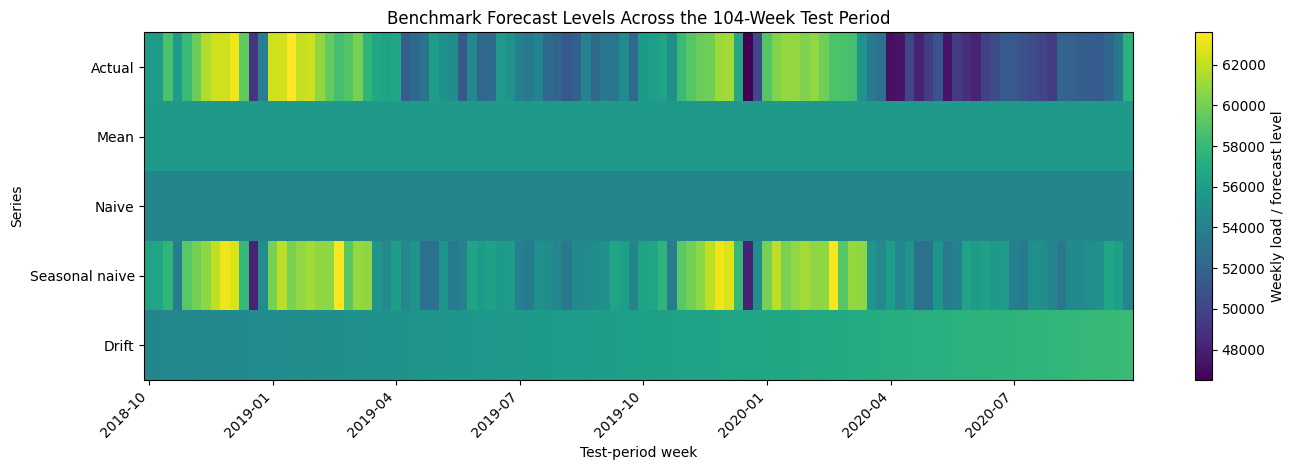

In [ ]:
benchmark_forecast_map_v4 = pd.DataFrame(
    {
        "Actual": test_load,
        "Mean": mean_guess,
        "Naive": naive_guess,
        "Seasonal naive": seasonal_guess,
        "Drift": drift_guess
    }
).T

fig, ax = plt.subplots(figsize=(14, 4.8))

benchmark_heat_v4 = ax.imshow(
    benchmark_forecast_map_v4.values,
    aspect="auto"
)

ax.set_title("Benchmark Forecast Levels Across the 104-Week Test Period")
ax.set_xlabel("Test-period week")
ax.set_ylabel("Series")

ax.set_yticks(np.arange(len(benchmark_forecast_map_v4.index)))
ax.set_yticklabels(benchmark_forecast_map_v4.index)

week_positions_v4 = np.arange(0, len(test_load), 13)
week_labels_v4 = [
    test_load.index[pos].strftime("%Y-%m")
    for pos in week_positions_v4
]

ax.set_xticks(week_positions_v4)
ax.set_xticklabels(week_labels_v4, rotation=45, ha="right")

cbar = plt.colorbar(benchmark_heat_v4, ax=ax)
cbar.set_label("Weekly load / forecast level")

plt.tight_layout()
plt.show()


In [ ]:
benchmark_errors = pd.DataFrame(
    {
        name: np.abs(test_load - forecast)
        for name, forecast in simple_forecasts.items()
    },
    index=test_load.index
)

benchmark_errors.head()

,Mean,Naive,Seasonal Naive,Drift
time,,,,
2018-10-14 00:00:00+00:00,198.395357,1561.880952,484.458333,1525.894626
2018-10-21 00:00:00+00:00,111.579881,1475.065476,795.184524,1403.092824
2018-10-28 00:00:00+00:00,3034.169167,4397.654762,997.000000,4289.695783
2018-11-04 00:00:00+00:00,267.044167,1630.529762,2209.880952,1486.584457
2018-11-11 00:00:00+00:00,2512.925119,3876.410714,1046.886905,3696.479083


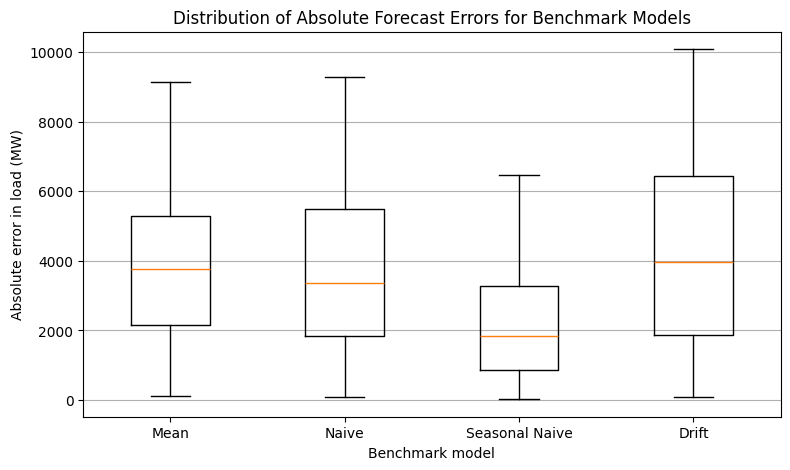

In [ ]:
# Boxplot of absolute errors for each benchmark model

error_lists = [
    benchmark_errors["Mean"],
    benchmark_errors["Naive"],
    benchmark_errors["Seasonal Naive"],
    benchmark_errors["Drift"]
]

model_names = [
    "Mean",
    "Naive",
    "Seasonal Naive",
    "Drift"
]

plt.figure(figsize=(9, 5))

plt.boxplot(
    error_lists,
    labels=model_names,
    showfliers=False
)

plt.title("Distribution of Absolute Forecast Errors for Benchmark Models")
plt.xlabel("Benchmark model")
plt.ylabel("Absolute error in load (MW)")
plt.grid(axis="y")
plt.show()

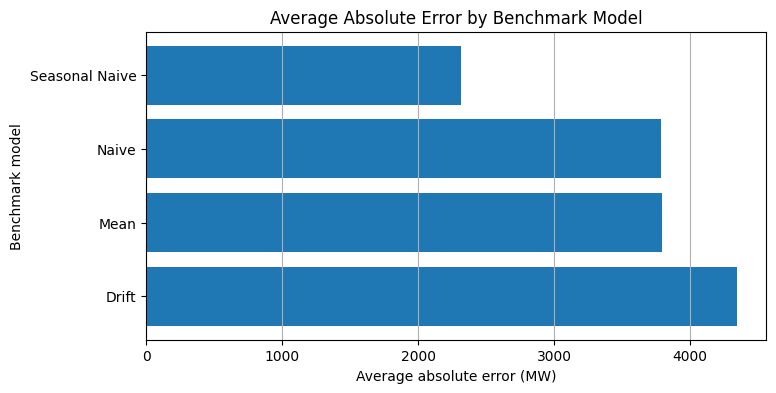

In [ ]:
# Average absolute error by benchmark model

average_error = (
    benchmark_errors
    .mean()
    .sort_values()
)

plt.figure(figsize=(8, 4))

plt.barh(
    average_error.index,
    average_error.values
)

plt.title("Average Absolute Error by Benchmark Model")
plt.xlabel("Average absolute error (MW)")
plt.ylabel("Benchmark model")
plt.gca().invert_yaxis()
plt.grid(axis="x")
plt.show()

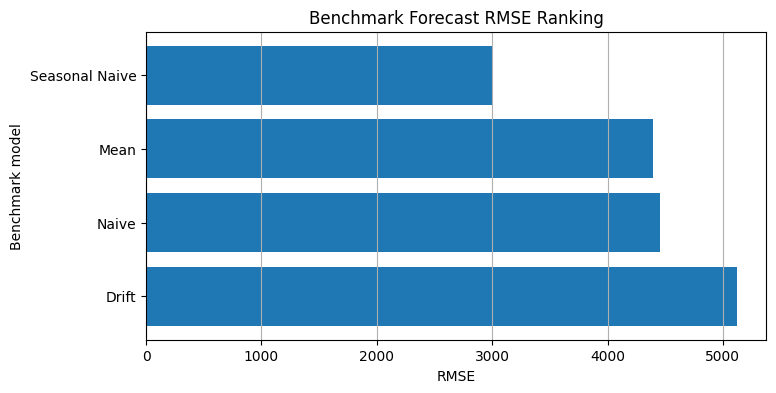

In [ ]:
# Simple error ranking plot

ordered_benchmarks = benchmark_table.sort_values(
    "RMSE",
    ascending=True
)

plt.figure(figsize=(8, 4))

plt.barh(
    ordered_benchmarks["Model"],
    ordered_benchmarks["RMSE"]
)

plt.title("Benchmark Forecast RMSE Ranking")
plt.xlabel("RMSE")
plt.ylabel("Benchmark model")
plt.gca().invert_yaxis()
plt.grid(axis="x")
plt.show()

In [ ]:
benchmark_result = pd.DataFrame(
    {
        "Model": ["Seasonal Naive"],
        "RMSE": [seasonal_naive_rmse],
        "MAE": [seasonal_naive_mae],
        "MAPE": [seasonal_naive_mape]
    }
)

benchmark_result

,Model,RMSE,MAE,MAPE
0,Seasonal Naive,3006.760812,2318.520585,4.40892


### PART3: MODEL SARIMA

In [ ]:
# Part 3 - SARIMA model

import itertools
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf
warnings.filterwarnings("ignore")

# The assignment requires p from 0 to 6, d from 0 to 2, and q from 0 to 6

p_choices = range(0, 7)
d_choices = range(0, 3)
q_choices = range(0, 7)

possible_orders = list(
    itertools.product(
        p_choices,
        d_choices,
        q_choices
    )
)

yearly_season = (1, 1, 1, 52)

print("Number of SARIMA orders to try:", len(possible_orders))
print("Seasonal order used:", yearly_season)

Number of SARIMA orders to try: 147
Seasonal order used: (1, 1, 1, 52)


In [ ]:
# Trying each SARIMA order and saving the AIC value

sarima_rows = []

for count, order_used in enumerate(possible_orders, start=1):

    try:
        trial_model = SARIMAX(
            train_load,
            order=order_used,
            seasonal_order=yearly_season,
            enforce_stationarity=False,
            enforce_invertibility=False
        )

        trial_fit = trial_model.fit(
            disp=False,
            maxiter=80
        )

        sarima_rows.append(
            {
                "Order": order_used,
                "Seasonal Order": yearly_season,
                "AIC": trial_fit.aic,
                "Worked": "Yes"
            }
        )

    except:
        sarima_rows.append(
            {
                "Order": order_used,
                "Seasonal Order": yearly_season,
                "AIC": np.nan,
                "Worked": "No"
            }
        )

    if count % 20 == 0:
        print("Checked", count, "models")

Checked 20 models
Checked 40 models
Checked 60 models
Checked 80 models
Checked 100 models
Checked 120 models
Checked 140 models


In [ ]:
# AIC result table

sarima_aic_table = pd.DataFrame(sarima_rows)

sarima_aic_table = (
    sarima_aic_table
    .dropna(subset=["AIC"])
    .sort_values("AIC")
    .reset_index(drop=True)
)

sarima_aic_table.head(10)

,Order,Seasonal Order,AIC,Worked
0,"(2, 2, 6)","(1, 1, 1, 52)",1481.906028,Yes
1,"(1, 2, 6)","(1, 1, 1, 52)",1482.964917,Yes
2,"(3, 2, 6)","(1, 1, 1, 52)",1483.069075,Yes
3,"(4, 2, 6)","(1, 1, 1, 52)",1484.877037,Yes
4,"(0, 2, 6)","(1, 1, 1, 52)",1485.773839,Yes
5,"(5, 2, 6)","(1, 1, 1, 52)",1486.257384,Yes
6,"(6, 2, 6)","(1, 1, 1, 52)",1486.461119,Yes
7,"(0, 1, 6)","(1, 1, 1, 52)",1490.461384,Yes
8,"(1, 1, 6)","(1, 1, 1, 52)",1491.630999,Yes
9,"(4, 1, 6)","(1, 1, 1, 52)",1492.288213,Yes


In [ ]:
# Plot the best SARIMA orders by AIC

aic_top = sarima_aic_table.head(10).copy()

aic_top["Order Name"] = aic_top["Order"].astype(str)

plt.figure(figsize=(10, 5))

plt.barh(
    aic_top["Order Name"],
    aic_top["AIC"]
)

plt.title("Top SARIMA Orders Based on AIC")
plt.xlabel("AIC")
plt.ylabel("SARIMA order")
plt.gca().invert_yaxis()
plt.grid(axis="x")
plt.show()

In [ ]:
# Selecting the order with the lowest AIC

best_order = sarima_aic_table.loc[0, "Order"]

print("Best SARIMA order from AIC:", best_order)
print("Seasonal order:", yearly_season)

In [41]:
# Fitting the selected SARIMA model

sarima_model = SARIMAX(
    train_load,
    order=best_order,
    seasonal_order=yearly_season,
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_fit = sarima_model.fit(
    disp=False,
    maxiter=120
)

print(sarima_fit.summary())

                                      SARIMAX Results                                       
Dep. Variable:                                 load   No. Observations:                  197
Model:             SARIMAX(2, 2, 6)x(1, 1, [1], 52)   Log Likelihood                -729.642
Date:                              Mon, 13 Jul 2026   AIC                           1481.285
Time:                                      07:52:46   BIC                           1508.024
Sample:                                  01-04-2015   HQIC                          1492.034
                                       - 10-07-2018                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -1.0386      0.059    -17.605      0.000      -1.154      -0.923
ar.L2         -0.97

In [42]:
# Forecasting the test period

sarima_output = sarima_fit.get_forecast(
    steps=len(test_load)
)

sarima_forecast = sarima_output.predicted_mean
sarima_forecast.index = test_load.index

sarima_range = sarima_output.conf_int()
sarima_range.index = test_load.index

sarima_forecast.head()

,predicted_mean
time,
2018-10-14 00:00:00+00:00,58566.759930
2018-10-21 00:00:00+00:00,58903.203765
2018-10-28 00:00:00+00:00,59398.366855
2018-11-04 00:00:00+00:00,57028.641513
2018-11-11 00:00:00+00:00,61863.932135


In [43]:
# SARIMA error values

sarima_rmse, sarima_mae, sarima_mape = model_errors(
    test_load,
    sarima_forecast
)

print("SARIMA results")
print("RMSE:", sarima_rmse)
print("MAE:", sarima_mae)
print("MAPE:", sarima_mape)

SARIMA results
RMSE: 9230.673409226174
MAE: 7924.197337147429
MAPE: 14.893983326323157


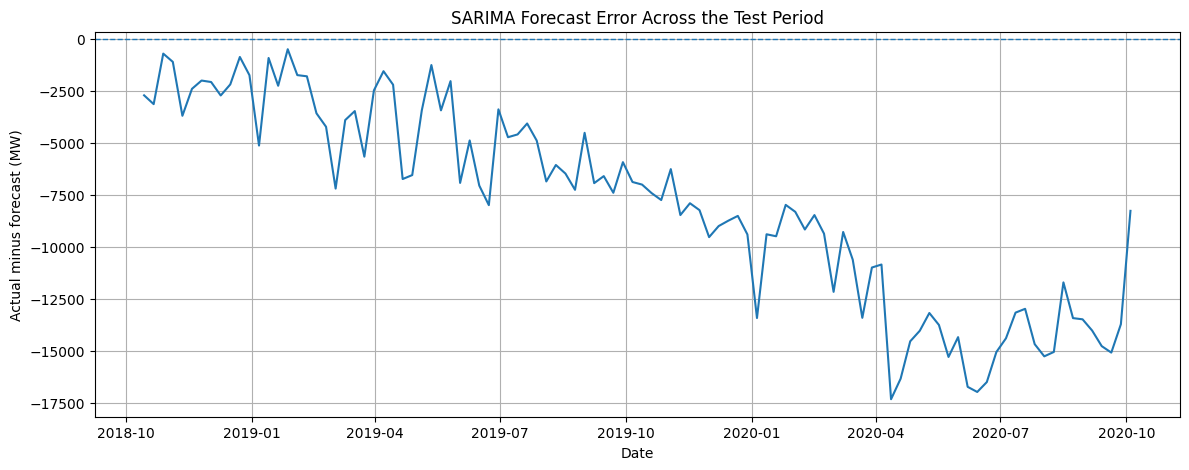

In [44]:
# Forecast error over the test period

sarima_error_line = test_load - sarima_forecast

plt.figure(figsize=(14, 5))

plt.plot(
    sarima_error_line.index,
    sarima_error_line
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.title("SARIMA Forecast Error Across the Test Period")
plt.xlabel("Date")
plt.ylabel("Actual minus forecast (MW)")
plt.grid(True)
plt.show()

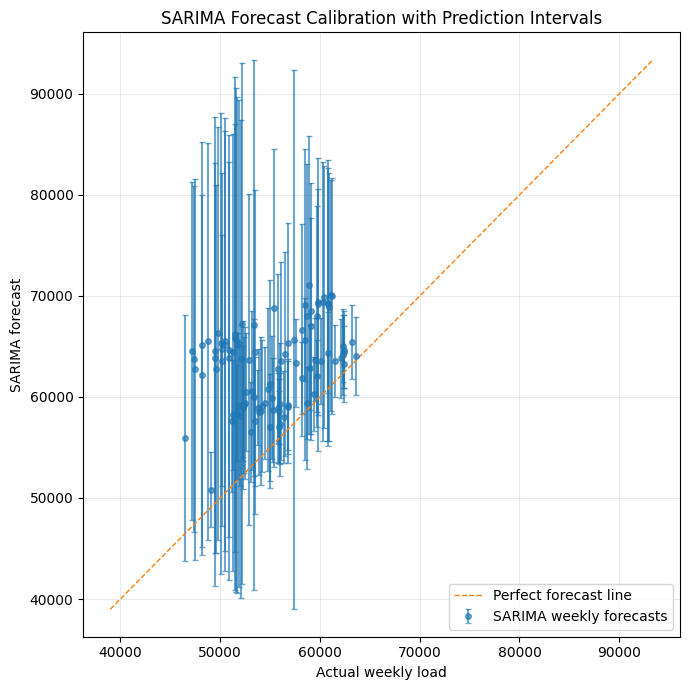

In [45]:
sarima_lower_v4 = sarima_range.iloc[:, 0].reindex(test_load.index)
sarima_upper_v4 = sarima_range.iloc[:, 1].reindex(test_load.index)
sarima_point_v4 = sarima_forecast.reindex(test_load.index)

sarima_yerr_v4 = np.vstack(
    [
        sarima_point_v4.values - sarima_lower_v4.values,
        sarima_upper_v4.values - sarima_point_v4.values
    ]
)

axis_min_v4 = min(test_load.min(), sarima_lower_v4.min())
axis_max_v4 = max(test_load.max(), sarima_upper_v4.max())

plt.figure(figsize=(7, 7))

plt.errorbar(
    test_load.values,
    sarima_point_v4.values,
    yerr=sarima_yerr_v4,
    fmt="o",
    alpha=0.65,
    capsize=2,
    markersize=4,
    label="SARIMA weekly forecasts"
)

plt.plot(
    [axis_min_v4, axis_max_v4],
    [axis_min_v4, axis_max_v4],
    linestyle="--",
    linewidth=1,
    label="Perfect forecast line"
)

plt.title("SARIMA Forecast Calibration with Prediction Intervals")
plt.xlabel("Actual weekly load")
plt.ylabel("SARIMA forecast")
plt.legend()
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()


In [46]:
# Residual values from SARIMA

sarima_leftover = sarima_fit.resid.dropna()

leftover_summary = pd.DataFrame(
    {
        "Item": [
            "Average residual",
            "Residual standard deviation",
            "Smallest residual",
            "Largest residual"
        ],
        "Value": [
            sarima_leftover.mean(),
            sarima_leftover.std(),
            sarima_leftover.min(),
            sarima_leftover.max()
        ]
    }
)

leftover_summary

,Item,Value
0,Average residual,509.189925
1,Residual standard deviation,5637.881834
2,Smallest residual,-27965.890575
3,Largest residual,47233.739583


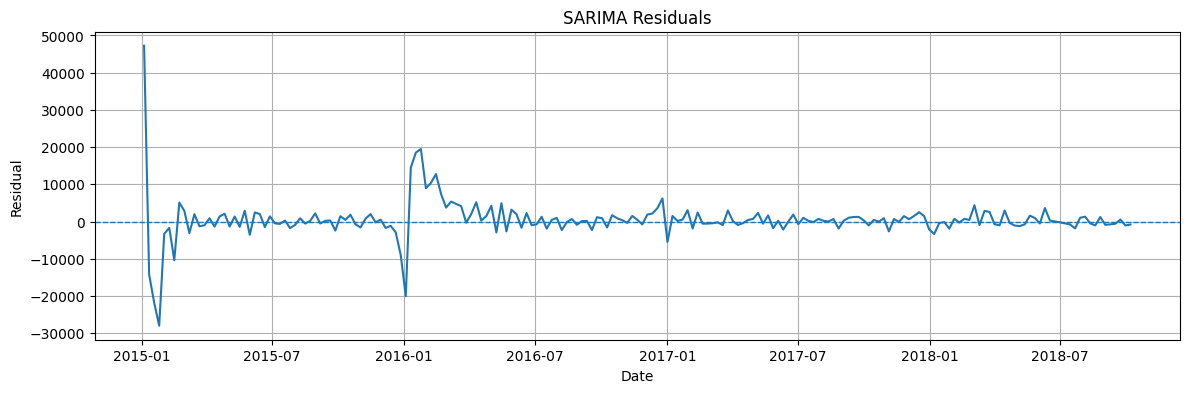

In [47]:
# Residuals through time

plt.figure(figsize=(14, 4))

plt.plot(
    sarima_leftover.index,
    sarima_leftover
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.title("SARIMA Residuals")
plt.xlabel("Date")
plt.ylabel("Residual")
plt.grid(True)
plt.show()

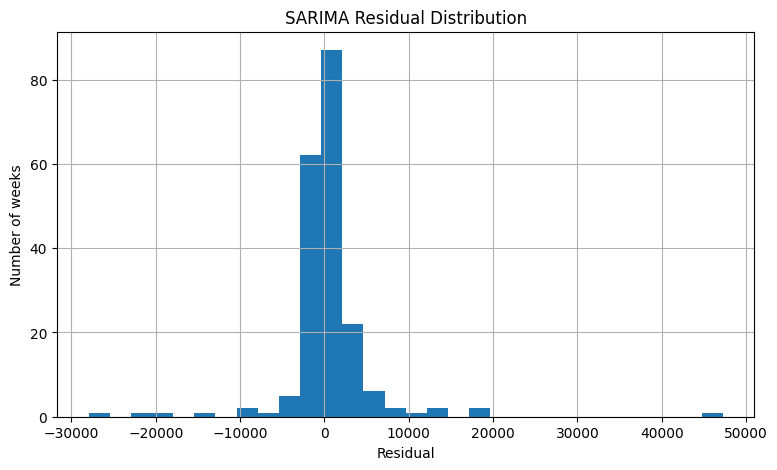

In [48]:
# Residual histogram

plt.figure(figsize=(9, 5))

plt.hist(
    sarima_leftover,
    bins=30
)

plt.title("SARIMA Residual Distribution")
plt.xlabel("Residual")
plt.ylabel("Number of weeks")
plt.grid(True)
plt.show()

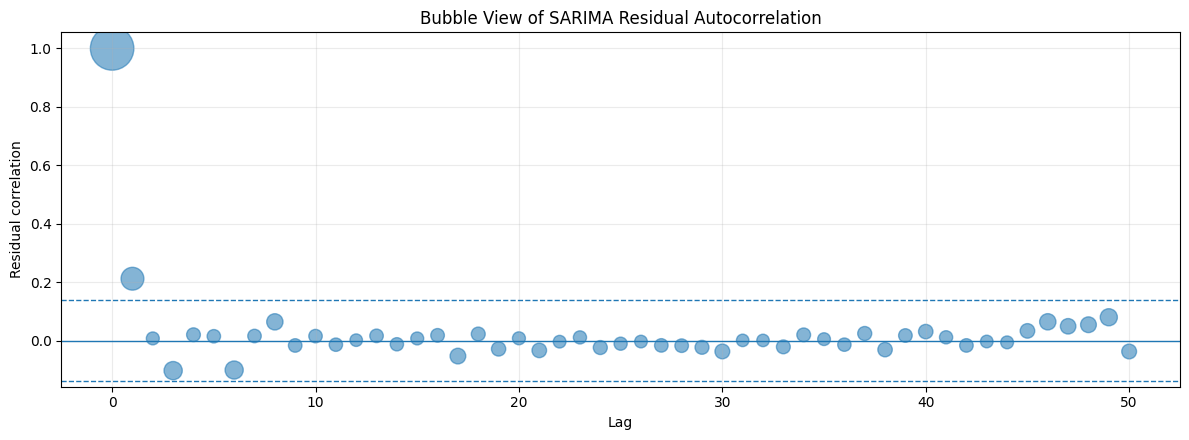

In [49]:
# For the SARIMA residual check, I used a bubble-style lag plot

from statsmodels.tsa.stattools import acf

resid_clean_v4 = sarima_leftover.dropna()
max_resid_lag_v4 = 50

resid_acf_v4 = acf(resid_clean_v4, nlags=max_resid_lag_v4, fft=True)
resid_lags_v4 = np.arange(max_resid_lag_v4 + 1)
resid_conf_v4 = 1.96 / np.sqrt(len(resid_clean_v4))

bubble_size_v4 = 80 + 900 * np.abs(resid_acf_v4)

plt.figure(figsize=(12, 4.5))

plt.scatter(
    resid_lags_v4,
    resid_acf_v4,
    s=bubble_size_v4,
    alpha=0.55
)

plt.axhline(0, linewidth=1)
plt.axhline(resid_conf_v4, linestyle="--", linewidth=1)
plt.axhline(-resid_conf_v4, linestyle="--", linewidth=1)

plt.title("Bubble View of SARIMA Residual Autocorrelation")
plt.xlabel("Lag")
plt.ylabel("Residual correlation")
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()


In [50]:
# Saving the SARIMA result

sarima_result = pd.DataFrame(
    {
        "Model": ["SARIMA"],
        "RMSE": [sarima_rmse],
        "MAE": [sarima_mae],
        "MAPE": [sarima_mape]
    }
)

sarima_result

,Model,RMSE,MAE,MAPE
0,SARIMA,9230.673409,7924.197337,14.893983


###PART 4: SARIMA INCLUDING THE WEATHER AND HOLIDAYS INFORMATION

In [51]:
# Part 4 - SARIMAX with weather and holiday information
import matplotlib.pyplot as plt
import requests

from statsmodels.tsa.statespace.sarimax import SARIMAX

!pip -q install holidays

import holidays

In [52]:
# Berlin weather is used as a representative German weather location

weather_url = (
    "https://archive-api.open-meteo.com/v1/archive?"
    "latitude=52.52&longitude=13.41"
    "&start_date=2015-01-01"
    "&end_date=2020-09-30"
    "&daily=temperature_2m_mean"
    "&timezone=UTC"
)

reply = requests.get(weather_url)
weather_json = reply.json()

weather_json.keys()

dict_keys(['latitude', 'longitude', 'generationtime_ms', 'utc_offset_seconds', 'timezone', 'timezone_abbreviation', 'elevation', 'daily_units', 'daily'])

In [53]:
# Making a small weather table

berlin = pd.DataFrame(
    {
        "day": weather_json["daily"]["time"],
        "temp": weather_json["daily"]["temperature_2m_mean"]
    }
)

berlin["day"] = pd.to_datetime(
    berlin["day"],
    utc=True
)

berlin = berlin.set_index("day")

berlin.head()

,temp
day,
2015-01-01 00:00:00+00:00,2.6
2015-01-02 00:00:00+00:00,4.9
2015-01-03 00:00:00+00:00,3.8
2015-01-04 00:00:00+00:00,2.8
2015-01-05 00:00:00+00:00,2.9


In [54]:
# Weather response variables
# Heating degree is high when temperature is below 18 degrees
# Cooling degree is high when temperature is above 22 degrees

berlin["heating_degree"] = np.maximum(
    18 - berlin["temp"],
    0
)

berlin["cooling_degree"] = np.maximum(
    berlin["temp"] - 22,
    0
)

berlin.head()

,temp,heating_degree,cooling_degree
day,,,
2015-01-01 00:00:00+00:00,2.6,15.4,0.0
2015-01-02 00:00:00+00:00,4.9,13.1,0.0
2015-01-03 00:00:00+00:00,3.8,14.2,0.0
2015-01-04 00:00:00+00:00,2.8,15.2,0.0
2015-01-05 00:00:00+00:00,2.9,15.1,0.0


In [55]:
# Weekly weather table to match weekly load

weekly_weather = berlin.resample("W").mean()

weekly_weather.head()

,temp,heating_degree,cooling_degree
day,,,
2015-01-04 00:00:00+00:00,3.525000,14.475000,0.0
2015-01-11 00:00:00+00:00,3.914286,14.085714,0.0
2015-01-18 00:00:00+00:00,4.842857,13.157143,0.0
2015-01-25 00:00:00+00:00,0.057143,17.942857,0.0
2015-02-01 00:00:00+00:00,1.400000,16.600000,0.0


In [56]:
# German public holidays

german_days_off = holidays.Germany(
    years=range(2015, 2021)
)

print("Holiday records:", len(german_days_off))

Holiday records: 55


In [57]:
# Daily holiday flag

holiday_daily = pd.Series(
    [
        1 if one_day.date() in german_days_off else 0
        for one_day in daily_load.index
    ],
    index=daily_load.index,
    name="holiday"
)

holiday_daily.head()

,holiday
time,
2015-01-01 00:00:00+00:00,1
2015-01-02 00:00:00+00:00,0
2015-01-03 00:00:00+00:00,0
2015-01-04 00:00:00+00:00,0
2015-01-05 00:00:00+00:00,0


In [58]:
# Weekly holiday count

weekly_holidays = holiday_daily.resample("W").sum()

weekly_holidays.head()

,holiday
time,
2015-01-04 00:00:00+00:00,1
2015-01-11 00:00:00+00:00,0
2015-01-18 00:00:00+00:00,0
2015-01-25 00:00:00+00:00,0
2015-02-01 00:00:00+00:00,0


In [59]:
# Putting load, weather and holiday information together

sarimax_table = pd.DataFrame(
    {
        "load": weekly_series,
        "temp": weekly_weather["temp"],
        "heating_degree": weekly_weather["heating_degree"],
        "cooling_degree": weekly_weather["cooling_degree"],
        "holiday_count": weekly_holidays
    }
)

sarimax_table = sarimax_table.dropna()

print("SARIMAX table shape:", sarimax_table.shape)
sarimax_table.head()

SARIMAX table shape: (301, 5)


,load,temp,heating_degree,cooling_degree,holiday_count
2015-01-04 00:00:00+00:00,47233.739583,3.525000,14.475000,0.0,1
2015-01-11 00:00:00+00:00,56191.101190,3.914286,14.085714,0.0,0
2015-01-18 00:00:00+00:00,57672.678571,4.842857,13.157143,0.0,0
2015-01-25 00:00:00+00:00,58613.303571,0.057143,17.942857,0.0,0
2015-02-01 00:00:00+00:00,58734.029762,1.400000,16.600000,0.0,0


In [60]:
# Simple correlation check

sarimax_table[
    [
        "load",
        "temp",
        "heating_degree",
        "cooling_degree",
        "holiday_count"
    ]
].corr()

,load,temp,heating_degree,cooling_degree,holiday_count
load,1.000000,-0.637328,0.668290,-0.161320,-0.464048
temp,-0.637328,1.000000,-0.983996,0.505930,-0.085544
heating_degree,0.668290,-0.983996,1.000000,-0.359350,0.063915
cooling_degree,-0.161320,0.505930,-0.359350,1.000000,-0.104102
holiday_count,-0.464048,-0.085544,0.063915,-0.104102,1.000000


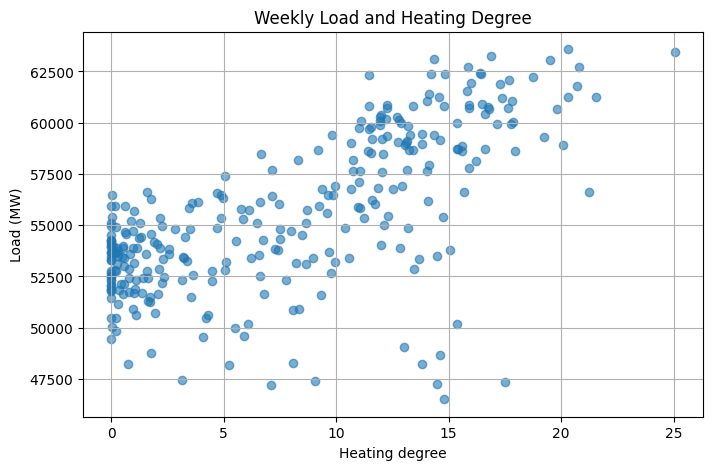

In [61]:
#graph: demand against heating degree

plt.figure(figsize=(8, 5))

plt.scatter(
    sarimax_table["heating_degree"],
    sarimax_table["load"],
    alpha=0.6
)

plt.title("Weekly Load and Heating Degree")
plt.xlabel("Heating degree")
plt.ylabel("Load (MW)")
plt.grid(True)
plt.show()

In [62]:
# Average load in holiday and non-holiday weeks

holiday_view = sarimax_table.copy()

holiday_view["week_type"] = np.where(
    holiday_view["holiday_count"] > 0,
    "Holiday week",
    "Normal week"
)

holiday_average = (
    holiday_view
    .groupby("week_type")["load"]
    .mean()
    .reset_index()
)

holiday_average

,week_type,load
0,Holiday week,51579.430123
1,Normal week,56206.914479


In [63]:
# Same 104-week split

weather_train = sarimax_table.iloc[:-last_two_years]
weather_test = sarimax_table.iloc[-last_two_years:]

y_train_weather = weather_train["load"]
y_test_weather = weather_test["load"]

print("Train rows:", len(y_train_weather))
print("Test rows:", len(y_test_weather))

Train rows: 197
Test rows: 104


In [64]:
# Function for running a SARIMAX model with chosen outside variables

def run_weather_model(name, train_columns, test_columns):

    model = SARIMAX(
        y_train_weather,
        exog=train_columns,
        order=best_order,
        seasonal_order=yearly_season,
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    fitted = model.fit(
        disp=False,
        maxiter=120
    )

    forecast_object = fitted.get_forecast(
        steps=len(y_test_weather),
        exog=test_columns
    )

    forecast = forecast_object.predicted_mean
    forecast.index = y_test_weather.index

    interval = forecast_object.conf_int()
    interval.index = y_test_weather.index

    rmse, mae, mape = model_errors(
        y_test_weather,
        forecast
    )

    row = {
        "Model": name,
        "RMSE": rmse,
        "MAE": mae,
        "MAPE": mape
    }

    return fitted, forecast, interval, row

In [65]:
#SARIMAX With Temperature only

temp_train = weather_train[
    [
        "temp"
    ]
]

temp_test = weather_test[
    [
        "temp"
    ]
]

temp_model, temp_forecast, temp_band, temp_row = run_weather_model(
    "SARIMAX Temperature",
    temp_train,
    temp_test
)

temp_row

{'Model': 'SARIMAX Temperature',
 'RMSE': np.float64(9044.02729349452),
 'MAE': 7804.3955299924955,
 'MAPE': np.float64(14.673352709762238)}

In [127]:
# Temperature coefficient

temp_model.params[
    temp_model.params.index.str.contains("temp")
]

,0
temp,-87.285119


After running the SARIMAX model with `heating_degree`, `cooling_degree`, and `holiday_count` as exogenous variables, we examine its performance metrics. The output below shows the RMSE, MAE, and MAPE for this model.

In [133]:
display(degree_row)

{'Model': 'SARIMAX Degree Days + Holidays',
 'RMSE': np.float64(6791.393274686237),
 'MAE': 5733.9075856103755,
 'MAPE': np.float64(10.831315931369762)}

Now, let's inspect the coefficients for the `heating_degree`, `cooling_degree`, and `holiday_count` variables within the fitted SARIMAX model. These coefficients indicate the impact of each variable on the electricity load forecast.

In [134]:
display(degree_model.params[degree_model.params.index.str.contains('heating_degree|cooling_degree|holiday_count')])

,0
heating_degree,176.990998
cooling_degree,76.725140
holiday_count,-1932.626217


In [139]:
# Weather-response and holiday SARIMAX

weather_holiday_train = weather_train[
    [
        "heating_degree",
        "cooling_degree",
        "holiday_count"
    ]
]

weather_holiday_test = weather_test[
    [
        "heating_degree",
        "cooling_degree",
        "holiday_count"
    ]
]

degree_model, degree_forecast, degree_band, degree_row = run_weather_model(
    "SARIMAX Degree Days + Holidays",
    weather_holiday_train,
    weather_holiday_test
)

degree_row

{'Model': 'SARIMAX Degree Days + Holidays',
 'RMSE': np.float64(6791.393274686237),
 'MAE': 5733.9075856103755,
 'MAPE': np.float64(10.831315931369762)}

In [140]:
# Coefficients for weather response and holiday variables

degree_model.params[
    degree_model.params.index.str.contains(
        "heating_degree|cooling_degree|holiday_count"
    )
]

,0
heating_degree,176.990998
cooling_degree,76.725140
holiday_count,-1932.626217


In [141]:
# Full SARIMAX covariate model

full_weather_train = weather_train[
    [
        "temp",
        "heating_degree",
        "cooling_degree",
        "holiday_count"
    ]
]

full_weather_test = weather_test[
    [
        "temp",
        "heating_degree",
        "cooling_degree",
        "holiday_count"
    ]
]

full_weather_model, full_weather_forecast, full_weather_band, full_weather_row = run_weather_model(
    "SARIMAX Full Weather + Holidays",
    full_weather_train,
    full_weather_test
)

full_weather_row

{'Model': 'SARIMAX Full Weather + Holidays',
 'RMSE': np.float64(4908.7417604229995),
 'MAE': 4012.852841029708,
 'MAPE': np.float64(7.6224047978765945)}

In [142]:
# SARIMA and SARIMAX comparison

sarimax_compare = pd.DataFrame(
    [
        {
            "Model": "SARIMA",
            "RMSE": sarima_rmse,
            "MAE": sarima_mae,
            "MAPE": sarima_mape
        },
        temp_row,
        degree_row,
        full_weather_row
    ]
)

sarimax_compare = (
    sarimax_compare
    .sort_values("RMSE")
    .reset_index(drop=True)
)

sarimax_compare

,Model,RMSE,MAE,MAPE
0,SARIMAX Full Weather + Holidays,4908.741760,4012.852841,7.622405
1,SARIMAX Degree Days + Holidays,6791.393275,5733.907586,10.831316
2,SARIMAX Temperature,9044.027293,7804.395530,14.673353
3,SARIMA,9230.673409,7924.197337,14.893983


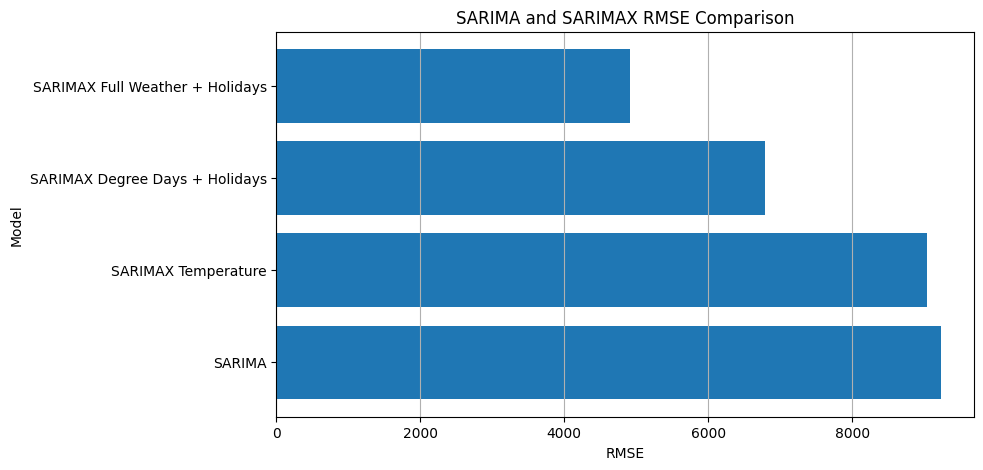

In [183]:
# Different comparison graph

plt.figure(figsize=(9, 5))

plt.barh(
    sarimax_compare["Model"],
    sarimax_compare["RMSE"]
)

plt.title("SARIMA and SARIMAX RMSE Comparison")
plt.xlabel("RMSE")
plt.ylabel("Model")
plt.gca().invert_yaxis()
plt.grid(axis="x")
plt.show()

In [144]:
# Choosing the best SARIMAX covariate model only

sarimax_only = sarimax_compare[
    sarimax_compare["Model"] != "SARIMA"
].copy()

best_sarimax_name = sarimax_only.iloc[0]["Model"]

print("Best SARIMAX covariate model:", best_sarimax_name)

Best SARIMAX covariate model: SARIMAX Full Weather + Holidays


In [145]:
# Matching the chosen name to the saved forecast

if best_sarimax_name == "SARIMAX Temperature":

    best_sarimax_fit = temp_model
    best_sarimax_forecast = temp_forecast
    best_sarimax_band = temp_band

elif best_sarimax_name == "SARIMAX Degree Days + Holidays":

    best_sarimax_fit = degree_model
    best_sarimax_forecast = degree_forecast
    best_sarimax_band = degree_band

else:

    best_sarimax_fit = full_weather_model
    best_sarimax_forecast = full_weather_forecast
    best_sarimax_band = full_weather_band

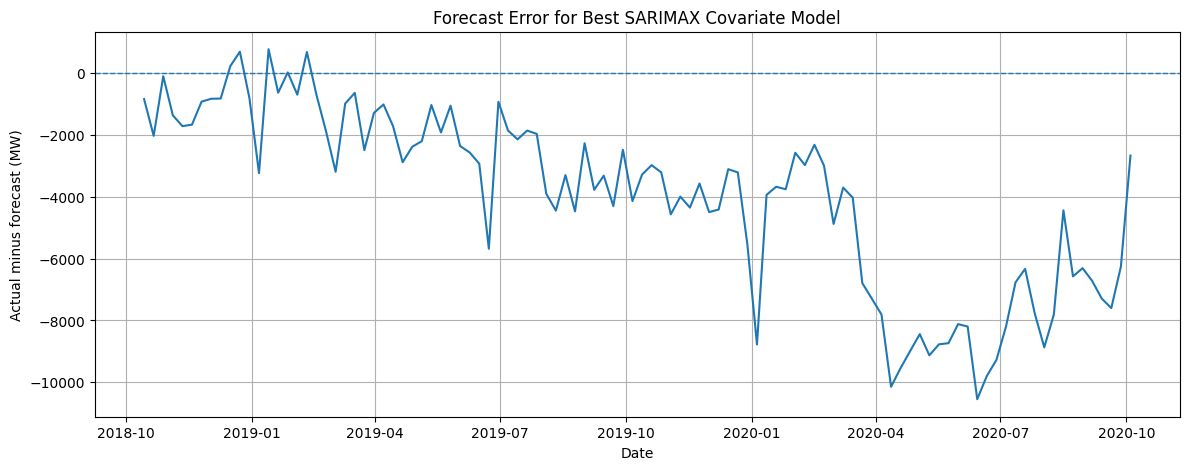

In [146]:
# Forecast error for the chosen SARIMAX model

sarimax_error = y_test_weather - best_sarimax_forecast

plt.figure(figsize=(14, 5))

plt.plot(
    sarimax_error.index,
    sarimax_error
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.title("Forecast Error for Best SARIMAX Covariate Model")
plt.xlabel("Date")
plt.ylabel("Actual minus forecast (MW)")
plt.grid(True)
plt.show()

In [147]:
# Saving result

best_sarimax_row = sarimax_only.iloc[0]

sarimax_result = pd.DataFrame(
    {
        "Model": [best_sarimax_row["Model"]],
        "RMSE": [best_sarimax_row["RMSE"]],
        "MAE": [best_sarimax_row["MAE"]],
        "MAPE": [best_sarimax_row["MAPE"]]
    }
)

sarimax_result

,Model,RMSE,MAE,MAPE
0,SARIMAX Full Weather + Holidays,4908.74176,4012.852841,7.622405


In [148]:
sarimax_rmse = sarimax_result["RMSE"].iloc[0]
sarimax_mae = sarimax_result["MAE"].iloc[0]
sarimax_mape = sarimax_result["MAPE"].iloc[0]

print("Best SARIMAX model:", best_sarimax_name)
print("RMSE:", sarimax_rmse)
print("MAE:", sarimax_mae)
print("MAPE:", sarimax_mape)

Best SARIMAX model: SARIMAX Full Weather + Holidays
RMSE: 4908.7417604229995
MAE: 4012.852841029708
MAPE: 7.6224047978765945


### PART5: GRADIENT BOOSTING + RANDOM FOREST(FOR COMPARING)

In [149]:
# Part 5 feature based models
# Main model: Gradient Boosting
# Extra comparison model: Random Forest

from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor

In [150]:
# Starting from the weekly table created in the SARIMAX section

model_sheet = sarimax_table.copy()

model_sheet.head()

,load,temp,heating_degree,cooling_degree,holiday_count
2015-01-04 00:00:00+00:00,47233.739583,3.525000,14.475000,0.0,1
2015-01-11 00:00:00+00:00,56191.101190,3.914286,14.085714,0.0,0
2015-01-18 00:00:00+00:00,57672.678571,4.842857,13.157143,0.0,0
2015-01-25 00:00:00+00:00,58613.303571,0.057143,17.942857,0.0,0
2015-02-01 00:00:00+00:00,58734.029762,1.400000,16.600000,0.0,0


In [151]:
# Past load values
# These are shifted, so the current week's load is not used as an input

for gap in [1, 2, 3, 4, 13, 26, 52]:

    model_sheet[f"load_before_{gap}"] = model_sheet["load"].shift(gap)

In [152]:
# Rolling summaries from past weeks only

model_sheet["past_4_week_average"] = (
    model_sheet["load"]
    .shift(1)
    .rolling(4)
    .mean()
)

model_sheet["past_8_week_median"] = (
    model_sheet["load"]
    .shift(1)
    .rolling(8)
    .median()
)

model_sheet["past_12_week_change"] = (
    model_sheet["load"]
    .shift(1)
    .rolling(12)
    .std()
)

In [153]:
# Calendar information

model_sheet["week"] = model_sheet.index.isocalendar().week.astype(int)
model_sheet["month"] = model_sheet.index.month

model_sheet["week_wave"] = np.sin(
    2 * np.pi * model_sheet["week"] / 52
)

model_sheet["week_cycle"] = np.cos(
    2 * np.pi * model_sheet["week"] / 52
)

model_sheet["month_wave"] = np.sin(
    2 * np.pi * model_sheet["month"] / 12
)

model_sheet["month_cycle"] = np.cos(
    2 * np.pi * model_sheet["month"] / 12
)

In [154]:
# Removing the rows made missing by lag and rolling calculations

model_sheet = model_sheet.dropna()

print("Rows and columns for machine learning:", model_sheet.shape)
model_sheet.head()

Rows and columns for machine learning: (249, 21)


,load,temp,heating_degree,cooling_degree,holiday_count,load_before_1,load_before_2,load_before_3,load_before_4,load_before_13,...,load_before_52,past_4_week_average,past_8_week_median,past_12_week_change,week,month,week_wave,week_cycle,month_wave,month_cycle
2016-01-03 00:00:00+00:00,47364.035714,0.514286,17.485714,0.0,1,48253.363095,57627.857143,59907.333333,60106.678571,53404.547619,...,47233.739583,56473.808036,58936.693452,3388.841029,53,1,0.120537,0.992709,0.5,0.866025
2016-01-10 00:00:00+00:00,56615.142857,-3.228571,21.228571,0.0,0,47364.035714,48253.363095,57627.857143,59907.333333,54714.547619,...,56191.101190,53288.147321,58936.693452,4354.952831,1,1,0.120537,0.992709,0.5,0.866025
2016-01-17 00:00:00+00:00,59913.910714,0.228571,17.771429,0.0,0,56615.142857,47364.035714,48253.363095,57627.857143,56243.970238,...,57672.678571,52465.099702,58505.014881,4355.597091,2,1,0.239316,0.970942,0.5,0.866025
2016-01-24 00:00:00+00:00,61267.529762,-3.542857,21.542857,0.0,0,59913.910714,56615.142857,47364.035714,48253.363095,55763.964286,...,58613.303571,53036.613095,58767.595238,4467.130964,3,1,0.354605,0.935016,0.5,0.866025
2016-01-31 00:00:00+00:00,59185.089286,6.400000,11.600000,0.0,0,61267.529762,59913.910714,56615.142857,47364.035714,55601.589286,...,58734.029762,56290.154762,58767.595238,4635.840939,4,1,0.464723,0.885456,0.5,0.866025


In [155]:
# Inputs used

past_load_columns = [
    "load_before_1",
    "load_before_2",
    "load_before_3",
    "load_before_4",
    "load_before_13",
    "load_before_26",
    "load_before_52"
]

rolling_columns = [
    "past_4_week_average",
    "past_8_week_median",
    "past_12_week_change"
]

weather_columns = [
    "temp",
    "heating_degree",
    "cooling_degree"
]

holiday_calendar_columns = [
    "holiday_count",
    "week_wave",
    "week_cycle",
    "month_wave",
    "month_cycle"
]

all_inputs = (
    past_load_columns
    + rolling_columns
    + weather_columns
    + holiday_calendar_columns
)

print("Total input columns:", len(all_inputs))

Total input columns: 18


In [156]:
x_all = model_sheet[all_inputs]
y_all = model_sheet["load"]

x_all.head()

,load_before_1,load_before_2,load_before_3,load_before_4,load_before_13,load_before_26,load_before_52,past_4_week_average,past_8_week_median,past_12_week_change,temp,heating_degree,cooling_degree,holiday_count,week_wave,week_cycle,month_wave,month_cycle
2016-01-03 00:00:00+00:00,48253.363095,57627.857143,59907.333333,60106.678571,53404.547619,54222.988095,47233.739583,56473.808036,58936.693452,3388.841029,0.514286,17.485714,0.0,1,0.120537,0.992709,0.5,0.866025
2016-01-10 00:00:00+00:00,47364.035714,48253.363095,57627.857143,59907.333333,54714.547619,53877.928571,56191.101190,53288.147321,58936.693452,4354.952831,-3.228571,21.228571,0.0,0,0.120537,0.992709,0.5,0.866025
2016-01-17 00:00:00+00:00,56615.142857,47364.035714,48253.363095,57627.857143,56243.970238,53722.517857,57672.678571,52465.099702,58505.014881,4355.597091,0.228571,17.771429,0.0,0,0.239316,0.970942,0.5,0.866025
2016-01-24 00:00:00+00:00,59913.910714,56615.142857,47364.035714,48253.363095,55763.964286,53660.047619,58613.303571,53036.613095,58767.595238,4467.130964,-3.542857,21.542857,0.0,0,0.354605,0.935016,0.5,0.866025
2016-01-31 00:00:00+00:00,61267.529762,59913.910714,56615.142857,47364.035714,55601.589286,52311.184524,58734.029762,56290.154762,58767.595238,4635.840939,6.400000,11.600000,0.0,0,0.464723,0.885456,0.5,0.866025


In [157]:
# Same 104-week test period

cut_here = len(model_sheet) - last_two_years

x_train = x_all.iloc[:cut_here]
x_test = x_all.iloc[cut_here:]

y_train = y_all.iloc[:cut_here]
y_test = y_all.iloc[cut_here:]

print("Training rows:", len(x_train))
print("Testing rows:", len(x_test))

Training rows: 145
Testing rows: 104


In [158]:
# Trying samples on Gradient Boosting

boosting_choices = [
    {
        "Name": "Small boosting model",
        "Trees": 150,
        "Learning rate": 0.05,
        "Depth": 2
    },
    {
        "Name": "Balanced boosting model",
        "Trees": 250,
        "Learning rate": 0.04,
        "Depth": 3
    },
    {
        "Name": "Larger boosting model",
        "Trees": 350,
        "Learning rate": 0.03,
        "Depth": 3
    }
]

In [159]:
boosting_rows = []
boosting_models = {}

for choice in boosting_choices:

    gb = GradientBoostingRegressor(
        n_estimators=choice["Trees"],
        learning_rate=choice["Learning rate"],
        max_depth=choice["Depth"],
        random_state=42
    )

    gb.fit(
        x_train,
        y_train
    )

    gb_guess = gb.predict(
        x_test
    )

    rmse, mae, mape = model_errors(
        y_test,
        gb_guess
    )

    boosting_rows.append(
        {
            "Model": choice["Name"],
            "Trees": choice["Trees"],
            "Learning rate": choice["Learning rate"],
            "Depth": choice["Depth"],
            "RMSE": rmse,
            "MAE": mae,
            "MAPE": mape
        }
    )

    boosting_models[choice["Name"]] = gb

boosting_table = (
    pd.DataFrame(boosting_rows)
    .sort_values("RMSE")
    .reset_index(drop=True)
)

boosting_table

,Model,Trees,Learning rate,Depth,RMSE,MAE,MAPE
0,Small boosting model,150,0.05,2,2484.774605,1874.092034,3.580260
1,Balanced boosting model,250,0.04,3,2500.494027,1853.138577,3.548234
2,Larger boosting model,350,0.03,3,2507.438601,1846.069329,3.537568


In [160]:
# Select best Gradient Boosting model

best_boost_name = boosting_table.loc[0, "Model"]

best_boost_model = boosting_models[best_boost_name]

print("Selected Gradient Boosting model:", best_boost_name)

Selected Gradient Boosting model: Small boosting model


In [161]:
boost_guess = best_boost_model.predict(
    x_test
)

boost_forecast = pd.Series(
    boost_guess,
    index=y_test.index,
    name="Gradient Boosting Forecast"
)

boost_rmse, boost_mae, boost_mape = model_errors(
    y_test,
    boost_forecast
)

print("Gradient Boosting results")
print("RMSE:", boost_rmse)
print("MAE:", boost_mae)
print("MAPE:", boost_mape)

Gradient Boosting results
RMSE: 2484.7746048023846
MAE: 1874.092033701786
MAPE: 3.580260386932102


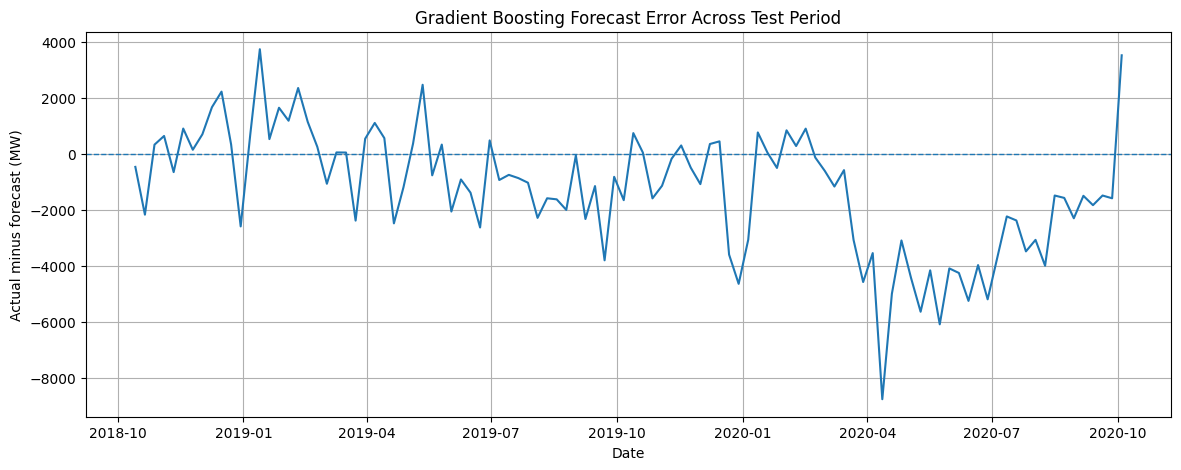

In [162]:
# Forecast error

boost_error = y_test - boost_forecast

plt.figure(figsize=(14, 5))

plt.plot(
    boost_error.index,
    boost_error
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.title("Gradient Boosting Forecast Error Across Test Period")
plt.xlabel("Date")
plt.ylabel("Actual minus forecast (MW)")
plt.grid(True)
plt.show()

In [163]:
# Feature importance from Gradient Boosting

boost_importance = pd.DataFrame(
    {
        "Input": all_inputs,
        "Importance": best_boost_model.feature_importances_
    }
)

boost_importance = (
    boost_importance
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

boost_importance.head(12)

,Input,Importance
0,load_before_52,0.778507
1,load_before_1,0.103095
2,holiday_count,0.036707
3,heating_degree,0.020825
4,load_before_3,0.013190
5,temp,0.011048
6,past_8_week_median,0.009318
7,week_cycle,0.007166
8,load_before_26,0.007033
9,past_12_week_change,0.003266


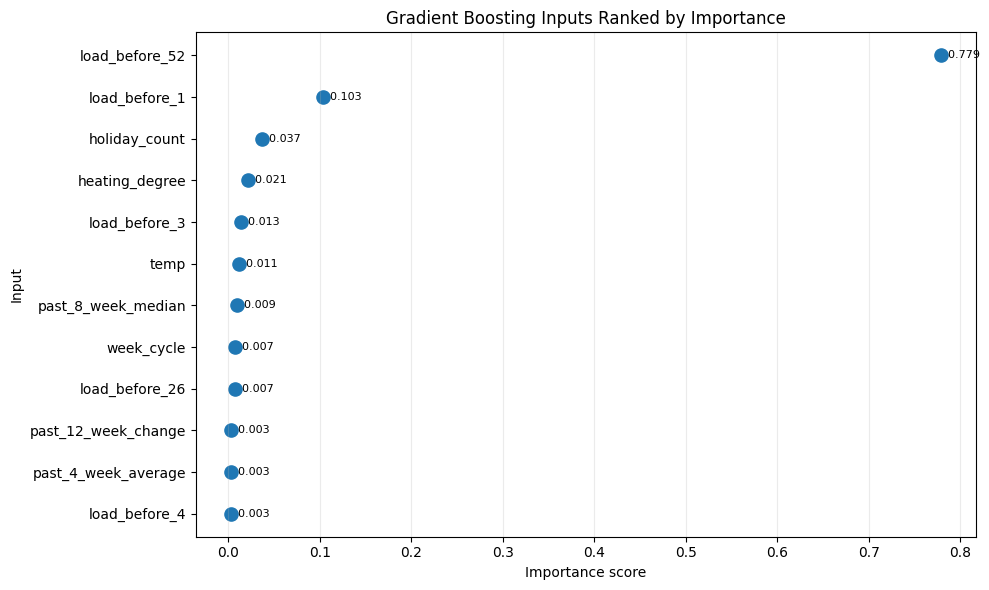

In [164]:
top_boost_inputs = boost_importance.head(12).copy()
top_boost_inputs = top_boost_inputs.iloc[::-1].reset_index(drop=True)

plt.figure(figsize=(10, 6))

plt.scatter(
    top_boost_inputs["Importance"],
    top_boost_inputs["Input"],
    s=90
)

for row_num, row in top_boost_inputs.iterrows():
    plt.text(
        row["Importance"],
        row["Input"],
        f"  {row['Importance']:.3f}",
        va="center",
        fontsize=8
    )

plt.title("Gradient Boosting Inputs Ranked by Importance")
plt.xlabel("Importance score")
plt.ylabel("Input")
plt.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()


In [165]:
# Extra model for comparison: Random Forest
# Random Forest is used as a second feature-based model for non-linear relationships

forest_choices = [
    {
        "Name": "Small Random Forest",
        "Trees": 200,
        "Depth": 8,
        "Min leaf": 2
    },
    {
        "Name": "Balanced Random Forest",
        "Trees": 400,
        "Depth": 12,
        "Min leaf": 2
    },
    {
        "Name": "Larger Random Forest",
        "Trees": 600,
        "Depth": None,
        "Min leaf": 1
    }
]

forest_rows = []
forest_models = {}

for choice in forest_choices:

    rf = RandomForestRegressor(
        n_estimators=choice["Trees"],
        max_depth=choice["Depth"],
        min_samples_leaf=choice["Min leaf"],
        random_state=42,
        n_jobs=-1
    )

    rf.fit(
        x_train,
        y_train
    )

    rf_prediction = rf.predict(
        x_test
    )

    rmse, mae, mape = model_errors(
        y_test,
        rf_prediction
    )

    forest_rows.append(
        {
            "Model": choice["Name"],
            "Trees": choice["Trees"],
            "Depth": choice["Depth"],
            "Min leaf": choice["Min leaf"],
            "RMSE": rmse,
            "MAE": mae,
            "MAPE": mape
        }
    )

    forest_models[choice["Name"]] = rf

forest_table = (
    pd.DataFrame(forest_rows)
    .sort_values("RMSE")
    .reset_index(drop=True)
)

forest_table

,Model,Trees,Depth,Min leaf,RMSE,MAE,MAPE
0,Small Random Forest,200,8.0,2,2456.336321,1799.712228,3.449297
1,Balanced Random Forest,400,12.0,2,2470.042146,1796.559848,3.447285
2,Larger Random Forest,600,NaN,1,2470.441735,1787.631844,3.432553


In [166]:
# Select best Random Forest model

best_forest_name = forest_table.loc[0, "Model"]
best_forest_model = forest_models[best_forest_name]

print("Selected Random Forest model:", best_forest_name)

forest_prediction = best_forest_model.predict(
    x_test
)

forest_forecast = pd.Series(
    forest_prediction,
    index=y_test.index,
    name="Random Forest Forecast"
)

forest_rmse, forest_mae, forest_mape = model_errors(
    y_test,
    forest_forecast
)

print("Random Forest results")
print("RMSE:", forest_rmse)
print("MAE:", forest_mae)
print("MAPE:", forest_mape)

Selected Random Forest model: Small Random Forest
Random Forest results
RMSE: 2456.3363214176225
MAE: 1799.7122282182604
MAPE: 3.4492969280151367


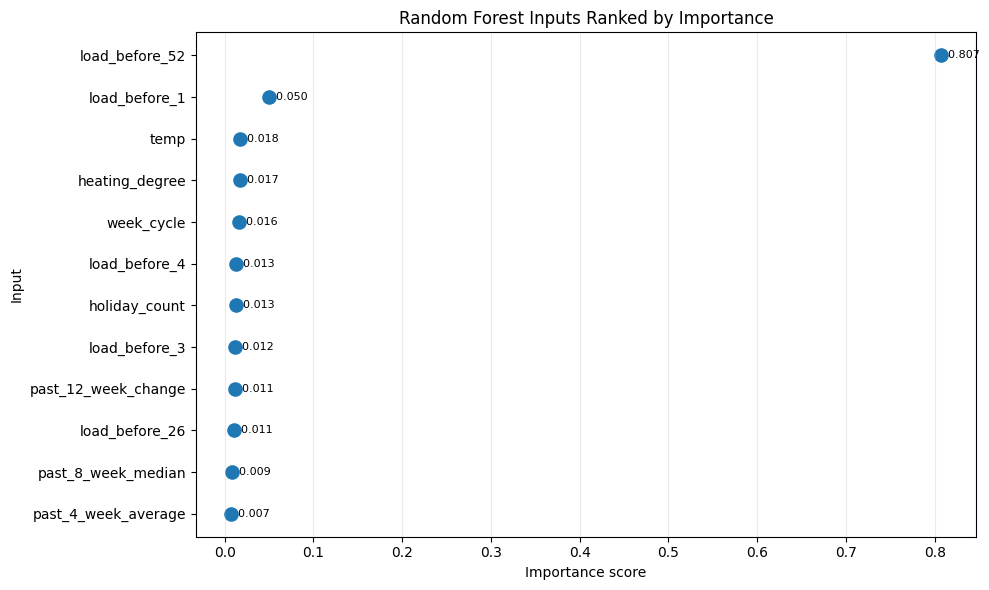

,Input,Importance
0,load_before_52,0.806905
1,load_before_1,0.050054
2,temp,0.017800
3,heating_degree,0.016848
4,week_cycle,0.015721
5,load_before_4,0.013012
6,holiday_count,0.012530
7,load_before_3,0.011741
8,past_12_week_change,0.011198
9,load_before_26,0.010605


In [167]:
forest_importance = pd.DataFrame(
    {
        "Input": all_inputs,
        "Importance": best_forest_model.feature_importances_
    }
)

forest_importance = (
    forest_importance
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

top_forest_inputs = forest_importance.head(12).copy()
top_forest_inputs = top_forest_inputs.iloc[::-1].reset_index(drop=True)

plt.figure(figsize=(10, 6))

plt.scatter(
    top_forest_inputs["Importance"],
    top_forest_inputs["Input"],
    s=90
)

for row_num, row in top_forest_inputs.iterrows():
    plt.text(
        row["Importance"],
        row["Input"],
        f"  {row['Importance']:.3f}",
        va="center",
        fontsize=8
    )

plt.title("Random Forest Inputs Ranked by Importance")
plt.xlabel("Importance score")
plt.ylabel("Input")
plt.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

forest_importance.head(12)


In [168]:
# Comparing the two feature based models

feature_compare = pd.DataFrame(
    [
        {
            "Model": "Gradient Boosting",
            "RMSE": boost_rmse,
            "MAE": boost_mae,
            "MAPE": boost_mape
        },
        {
            "Model": "Random Forest",
            "RMSE": forest_rmse,
            "MAE": forest_mae,
            "MAPE": forest_mape
        }
    ]
)

feature_compare.sort_values("RMSE")

,Model,RMSE,MAE,MAPE
1,Random Forest,2456.336321,1799.712228,3.449297
0,Gradient Boosting,2484.774605,1874.092034,3.580260


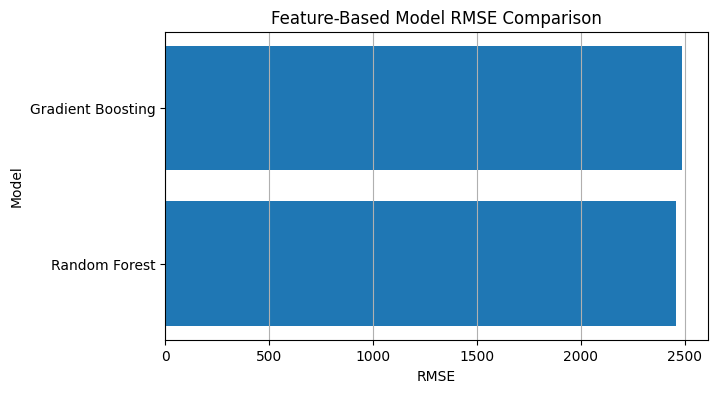

In [169]:
# Error comparison between feature based models

plt.figure(figsize=(7, 4))

plt.barh(
    feature_compare["Model"],
    feature_compare["RMSE"]
)

plt.title("Feature-Based Model RMSE Comparison")
plt.xlabel("RMSE")
plt.ylabel("Model")
plt.gca().invert_yaxis()
plt.grid(axis="x")
plt.show()

In [170]:
# Save Gradient Boosting

feature_model_result = pd.DataFrame(
    {
        "Model": ["Gradient Boosting"],
        "RMSE": [boost_rmse],
        "MAE": [boost_mae],
        "MAPE": [boost_mape]
    }
)

feature_model_result

,Model,RMSE,MAE,MAPE
0,Gradient Boosting,2484.774605,1874.092034,3.58026


In [171]:
# Save Random Forest as the extra model result

extra_model_result = pd.DataFrame(
    {
        "Model": ["Random Forest"],
        "RMSE": [forest_rmse],
        "MAE": [forest_mae],
        "MAPE": [forest_mape]
    }
)

extra_model_result

,Model,RMSE,MAE,MAPE
0,Random Forest,2456.336321,1799.712228,3.449297


### PART6: LSTM

In [172]:
# Part 6 - LSTM model on hourly electricity load
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import backend as K

In [173]:
 # The LSTM uses hourly data, not weekly data

hourly_for_lstm = germany[["load"]].copy()

print(hourly_for_lstm.head())
print(hourly_for_lstm.tail())
print("Hourly rows:", len(hourly_for_lstm))

                              load
time                              
2015-01-01 00:00:00+00:00  41151.0
2015-01-01 01:00:00+00:00  40135.0
2015-01-01 02:00:00+00:00  39106.0
2015-01-01 03:00:00+00:00  38765.0
2015-01-01 04:00:00+00:00  38941.0
                              load
time                              
2020-09-30 19:00:00+00:00  57559.0
2020-09-30 20:00:00+00:00  54108.0
2020-09-30 21:00:00+00:00  49845.0
2020-09-30 22:00:00+00:00  46886.0
2020-09-30 23:00:00+00:00  45461.0
Hourly rows: 50400


In [174]:
# Last two years of hourly observations are used for testing

two_year_hours = 24 * 365 * 2

train_hours = hourly_for_lstm.iloc[:-two_year_hours]
test_hours_data = hourly_for_lstm.iloc[-two_year_hours:]

print("Training hours:", len(train_hours))
print("Testing hours:", len(test_hours_data))

print("Train starts:", train_hours.index.min())
print("Train ends:", train_hours.index.max())

print("Test starts:", test_hours_data.index.min())
print("Test ends:", test_hours_data.index.max())

Training hours: 32880
Testing hours: 17520
Train starts: 2015-01-01 00:00:00+00:00
Train ends: 2018-10-01 23:00:00+00:00
Test starts: 2018-10-02 00:00:00+00:00
Test ends: 2020-09-30 23:00:00+00:00


In [175]:
# Fit the scaler only on training data to avoid leakage

scale_load = MinMaxScaler()

train_scaled = scale_load.fit_transform(train_hours)
test_scaled = scale_load.transform(test_hours_data)

print("Scaled train shape:", train_scaled.shape)
print("Scaled test shape:", test_scaled.shape)

Scaled train shape: (32880, 1)
Scaled test shape: (17520, 1)


In [176]:
def make_memory_blocks(values, hours_back):

    x_blocks = []
    y_blocks = []

    for row in range(hours_back, len(values)):

        x_blocks.append(values[row-hours_back:row])
        y_blocks.append(values[row, 0])

    return np.array(x_blocks), np.array(y_blocks)

In [177]:
# Function for one LSTM experiment

def run_memory_model(name, hours_back, first_layer, second_layer=None, dropout=0.2, epochs=5):

    K.clear_session()

    x_train_lstm, y_train_lstm = make_memory_blocks(
        train_scaled,
        hours_back
    )

    # For testing, the model needs the last training window before the test starts
    test_with_history = np.concatenate(
        [
            train_scaled[-hours_back:],
            test_scaled
        ]
    )

    x_test_lstm, y_test_lstm = make_memory_blocks(
        test_with_history,
        hours_back
    )

    net = Sequential()

    if second_layer is None:

        net.add(
            LSTM(
                first_layer,
                input_shape=(x_train_lstm.shape[1], x_train_lstm.shape[2])
            )
        )

        net.add(
            Dropout(dropout)
        )

    else:

        net.add(
            LSTM(
                first_layer,
                return_sequences=True,
                input_shape=(x_train_lstm.shape[1], x_train_lstm.shape[2])
            )
        )

        net.add(
            Dropout(dropout)
        )

        net.add(
            LSTM(second_layer)
        )

        net.add(
            Dropout(dropout)
        )

    net.add(Dense(1))

    net.compile(
        optimizer="adam",
        loss="mse"
    )

    stop_rule = EarlyStopping(
        monitor="val_loss",
        patience=2,
        restore_best_weights=True
    )

    history = net.fit(
        x_train_lstm,
        y_train_lstm,
        epochs=epochs,
        batch_size=128,
        validation_split=0.1,
        callbacks=[stop_rule],
        verbose=1
    )

    scaled_prediction = net.predict(
        x_test_lstm
    )

    prediction = scale_load.inverse_transform(
        scaled_prediction
    ).flatten()

    actual = scale_load.inverse_transform(
        y_test_lstm.reshape(-1, 1)
    ).flatten()

    rmse = np.sqrt(
        mean_squared_error(actual, prediction)
    )

    mae = mean_absolute_error(
        actual,
        prediction
    )

    mape = np.mean(
        np.abs((actual - prediction) / actual)
    ) * 100

    result = {
        "Model": name,
        "Lookback hours": hours_back,
        "Layers": str(first_layer) if second_layer is None else str(first_layer) + " + " + str(second_layer),
        "Dropout": dropout,
        "Epochs used": len(history.history["loss"]),
        "RMSE": rmse,
        "MAE": mae,
        "MAPE": mape
    }

    return net, history, prediction, actual, result

In [178]:
# Small tuning comparison
# 24 hours = previous day
# 168 hours = previous week
# 336 hours = previous two weeks

memory_choices = [
    {
        "name": "One Day Memory",
        "hours_back": 24,
        "first_layer": 32,
        "second_layer": None,
        "dropout": 0.20,
        "epochs": 4
    },
    {
        "name": "One Week Memory",
        "hours_back": 168,
        "first_layer": 48,
        "second_layer": 32,
        "dropout": 0.20,
        "epochs": 6
    },
    {
        "name": "Two Week Memory",
        "hours_back": 336,
        "first_layer": 64,
        "second_layer": 32,
        "dropout": 0.25,
        "epochs": 4
    }
]

In [179]:
# Run the LSTM experiments

memory_rows = []
saved_nets = {}
saved_history = {}
saved_predictions = {}
saved_actuals = {}

for choice in memory_choices:

    net, history, prediction, actual, result = run_memory_model(
        name=choice["name"],
        hours_back=choice["hours_back"],
        first_layer=choice["first_layer"],
        second_layer=choice["second_layer"],
        dropout=choice["dropout"],
        epochs=choice["epochs"]
    )

    memory_rows.append(result)
    saved_nets[choice["name"]] = net
    saved_history[choice["name"]] = history
    saved_predictions[choice["name"]] = prediction
    saved_actuals[choice["name"]] = actual

Epoch 1/4
232/232 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0405 - val_loss: 0.0133
Epoch 2/4
232/232 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0124 - val_loss: 0.0065
Epoch 3/4
232/232 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0097 - val_loss: 0.0074
Epoch 4/4
232/232 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0080 - val_loss: 0.0040
548/548 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Epoch 1/6
230/230 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - loss: 0.0309 - val_loss: 0.0061
Epoch 2/6
230/230 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step - loss: 0.0100 - val_loss: 0.0044
Epoch 3/6
230/230 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 0.0076 - val_loss: 0.0033
Epoch 4/6
230/230 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0061 - val_loss: 0.0016
Epoch 5/6
230/230 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 0.0052 - val_loss: 0.0013
Epoch 6/6
230/230 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - loss: 0.0045 - val_loss: 0.0015
548/548 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step
Epoch 1/4
229/229 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step - loss: 0.

In [180]:
# LSTM tuning comparison table

lstm_table = (
    pd.DataFrame(memory_rows)
    .sort_values("RMSE")
    .reset_index(drop=True)
)

lstm_table

,Model,Lookback hours,Layers,Dropout,Epochs used,RMSE,MAE,MAPE
0,One Week Memory,168,48 + 32,0.20,6,2117.016912,1593.376510,3.020041
1,Two Week Memory,336,64 + 32,0.25,4,2511.801598,1883.718057,3.636707
2,One Day Memory,24,32,0.20,4,2942.214495,2381.383467,4.561125


In [181]:
# Best LSTM based on RMSE

best_memory_name = lstm_table.loc[0, "Model"]

best_prediction = saved_predictions[best_memory_name]
best_actual = saved_actuals[best_memory_name]
best_history = saved_history[best_memory_name]

lstm_rmse = lstm_table.loc[0, "RMSE"]
lstm_mae = lstm_table.loc[0, "MAE"]
lstm_mape = lstm_table.loc[0, "MAPE"]

print("Selected LSTM:", best_memory_name)
print("RMSE:", lstm_rmse)
print("MAE:", lstm_mae)
print("MAPE:", lstm_mape)

Selected LSTM: One Week Memory
RMSE: 2117.016912432923
MAE: 1593.376509770084
MAPE: 3.0200408104307344


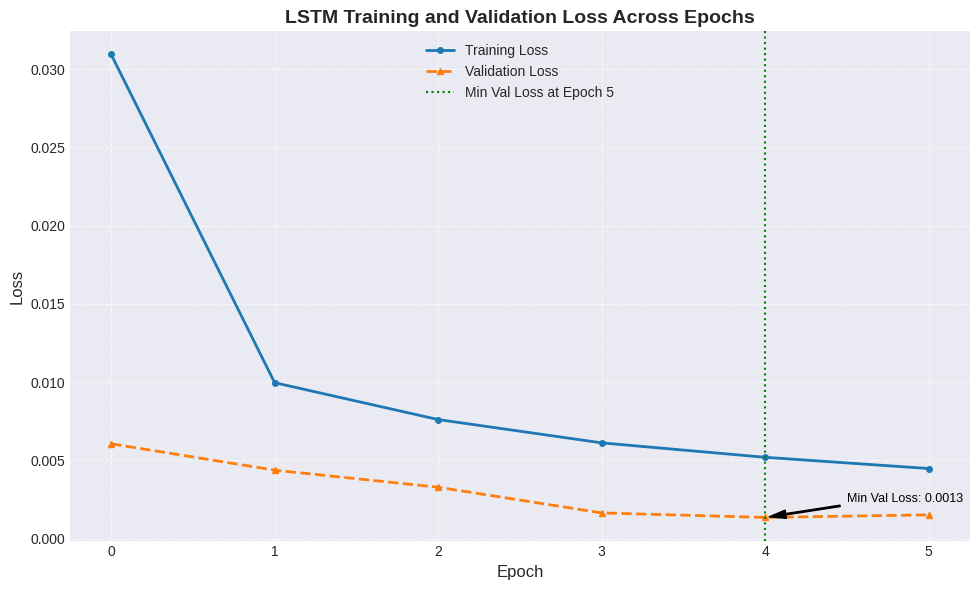

In [184]:
import numpy as np
import matplotlib.pyplot as plt

# Set a different plot style
plt.style.use('seaborn-v0_8-darkgrid')

plt.figure(figsize=(10, 6))

# Plotting training loss with a distinct color and marker
plt.plot(
    best_history.history["loss"],
    label="Training Loss",
    color='#1f77b4', # A shade of blue
    marker='o', # Circular markers
    linestyle='-', # Solid line style
    linewidth=2,
    markersize=4
)

# Plotting validation loss with a distinct color and marker
plt.plot(
    best_history.history["val_loss"],
    label="Validation Loss",
    color='#ff7f0e', # A shade of orange/red
    marker='^', # Triangular markers
    linestyle='--', # Dashed line style
    linewidth=2,
    markersize=4
)

# Find the epoch with the minimum validation loss to highlight it
best_val_loss_epoch = np.argmin(best_history.history['val_loss'])
best_val_loss_value = best_history.history['val_loss'][best_val_loss_epoch]

# Add a vertical line at the best validation loss epoch
plt.axvline(
    x=best_val_loss_epoch,
    color='green',
    linestyle=':',
    linewidth=1.5,
    label=f'Min Val Loss at Epoch {best_val_loss_epoch + 1}'
)

# Add an annotation for the minimum validation loss
plt.annotate(
    f'Min Val Loss: {best_val_loss_value:.4f}',
    xy=(best_val_loss_epoch, best_val_loss_value),
    xytext=(best_val_loss_epoch + 0.5, best_val_loss_value + 0.001),
    arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=6),
    fontsize=9,
    color='black'
)

plt.title("LSTM Training and Validation Loss Across Epochs", fontsize=14, fontweight='bold')
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Loss", fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()


In [185]:
# Create hourly actual and forecast series

lstm_actual_series = pd.Series(
    best_actual,
    index=test_hours_data.index,
    name="Actual load"
)

lstm_forecast_series = pd.Series(
    best_prediction,
    index=test_hours_data.index,
    name="LSTM forecast"
)

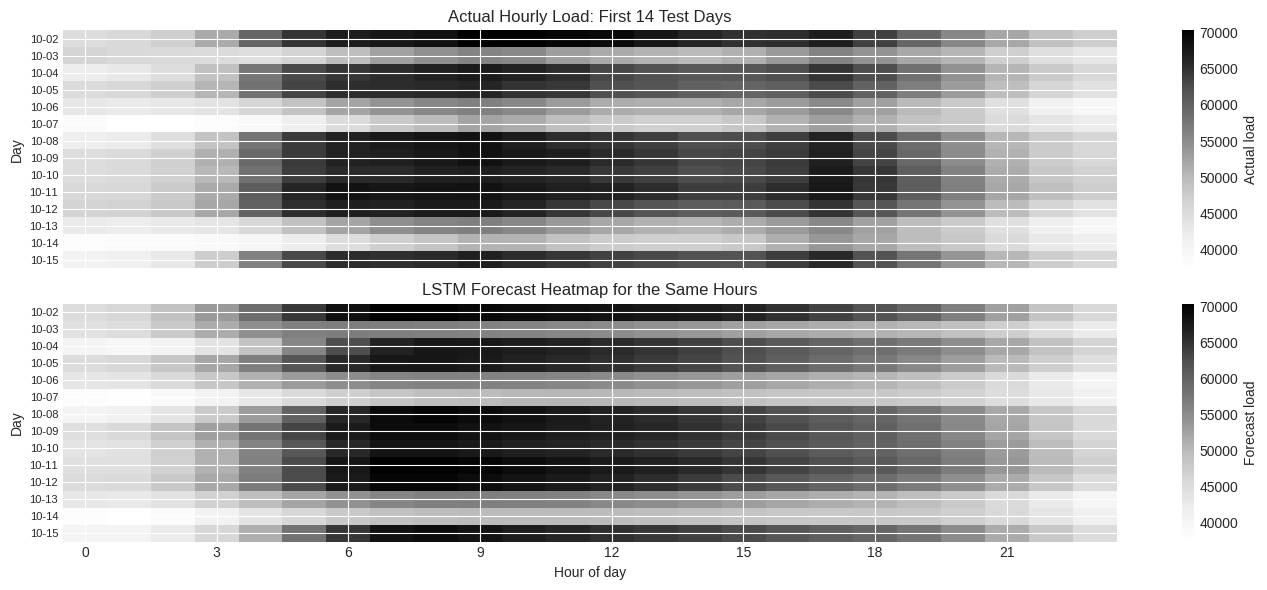

In [186]:
hours_to_show = 24 * 14

lstm_heat_actual_v4 = lstm_actual_series.iloc[:hours_to_show].copy()
lstm_heat_forecast_v4 = lstm_forecast_series.iloc[:hours_to_show].copy()

lstm_heat_data_v4 = pd.DataFrame(
    {
        "Actual": lstm_heat_actual_v4,
        "Forecast": lstm_heat_forecast_v4
    }
)

lstm_heat_data_v4["date"] = lstm_heat_data_v4.index.date
lstm_heat_data_v4["hour"] = lstm_heat_data_v4.index.hour

actual_matrix_v4 = lstm_heat_data_v4.pivot_table(
    index="date",
    columns="hour",
    values="Actual",
    aggfunc="mean"
)

forecast_matrix_v4 = lstm_heat_data_v4.pivot_table(
    index="date",
    columns="hour",
    values="Forecast",
    aggfunc="mean"
)

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

actual_heat_v4 = axes[0].imshow(
    actual_matrix_v4.values,
    aspect="auto"
)

axes[0].set_title("Actual Hourly Load: First 14 Test Days")
axes[0].set_ylabel("Day")
axes[0].set_yticks(np.arange(len(actual_matrix_v4.index)))
axes[0].set_yticklabels(
    [str(day)[5:] for day in actual_matrix_v4.index],
    fontsize=8
)

forecast_heat_v4 = axes[1].imshow(
    forecast_matrix_v4.values,
    aspect="auto"
)

axes[1].set_title("LSTM Forecast Heatmap for the Same Hours")
axes[1].set_xlabel("Hour of day")
axes[1].set_ylabel("Day")
axes[1].set_yticks(np.arange(len(forecast_matrix_v4.index)))
axes[1].set_yticklabels(
    [str(day)[5:] for day in forecast_matrix_v4.index],
    fontsize=8
)

axes[1].set_xticks(np.arange(0, 24, 3))
axes[1].set_xticklabels(np.arange(0, 24, 3))

fig.colorbar(actual_heat_v4, ax=axes[0], label="Actual load")
fig.colorbar(forecast_heat_v4, ax=axes[1], label="Forecast load")

plt.tight_layout()
plt.show()


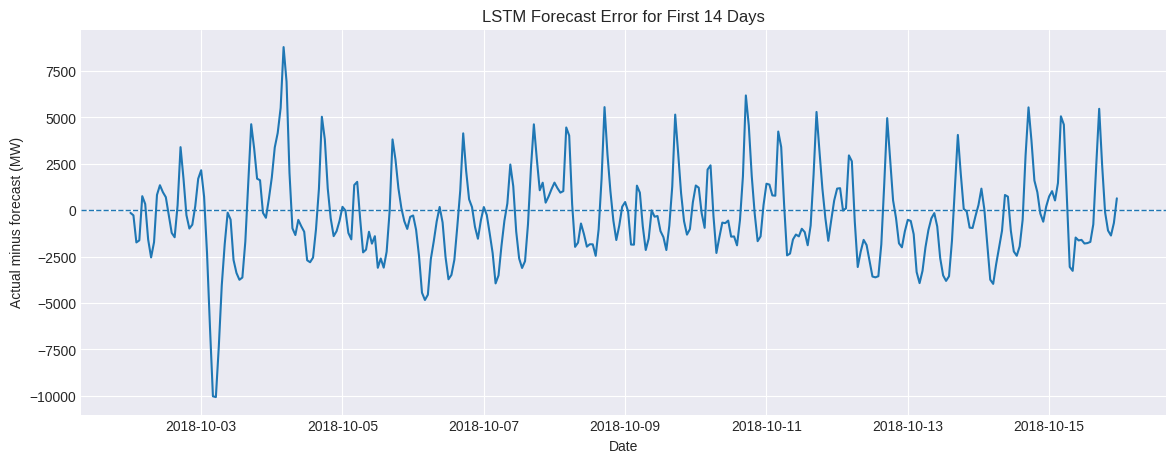

In [187]:
# Hourly error pattern

lstm_hourly_error = lstm_actual_series - lstm_forecast_series

plt.figure(figsize=(14, 5))

plt.plot(
    lstm_hourly_error.iloc[:24 * 14]
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.title("LSTM Forecast Error for First 14 Days")
plt.xlabel("Date")
plt.ylabel("Actual minus forecast (MW)")
plt.grid(True)
plt.show()

In [189]:
# Convert hourly LSTM forecast to weekly average

weekly_lstm_actual = lstm_actual_series.resample("W").mean()
weekly_lstm_forecast = lstm_forecast_series.resample("W").mean()

weekly_lstm_actual, weekly_lstm_forecast = weekly_lstm_actual.align(
    weekly_lstm_forecast,
    join="inner"
)

weekly_lstm_rmse, weekly_lstm_mae, weekly_lstm_mape = model_errors(
    weekly_lstm_actual,
    weekly_lstm_forecast
)

print("LSTM after weekly aggregation")
print("RMSE:", weekly_lstm_rmse)
print("MAE:", weekly_lstm_mae)
print("MAPE:", weekly_lstm_mape)

LSTM after weekly aggregation
RMSE: 328.7374037152523
MAE: 255.00900474773232
MAPE: 0.4832197213324504


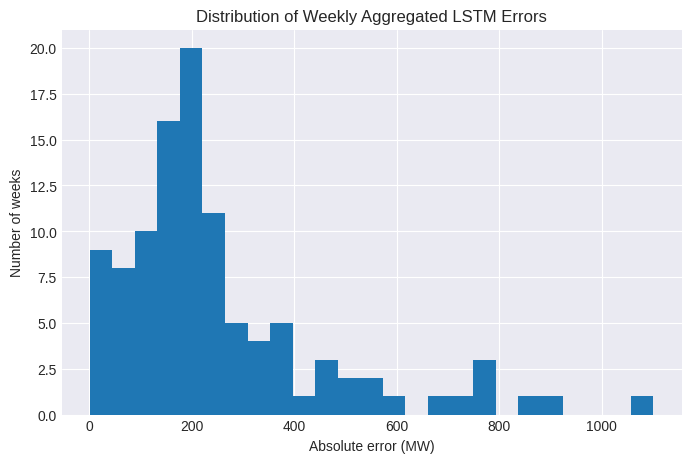

In [190]:
# Weekly LSTM error distribution

weekly_lstm_error = np.abs(
    weekly_lstm_actual - weekly_lstm_forecast
)

plt.figure(figsize=(8, 5))

plt.hist(
    weekly_lstm_error,
    bins=25
)

plt.title("Distribution of Weekly Aggregated LSTM Errors")
plt.xlabel("Absolute error (MW)")
plt.ylabel("Number of weeks")
plt.grid(True)
plt.show()

In [191]:
# Store hourly LSTM result for final comparison

lstm_result = pd.DataFrame(
    {
        "Model": ["LSTM"],
        "RMSE": [lstm_rmse],
        "MAE": [lstm_mae],
        "MAPE": [lstm_mape]
    }
)

lstm_result

,Model,RMSE,MAE,MAPE
0,LSTM,2117.016912,1593.37651,3.020041


In [192]:
# Store weekly aggregated LSTM also as an extra comparison

lstm_weekly_result = pd.DataFrame(
    {
        "Model": ["LSTM Weekly Aggregated"],
        "RMSE": [weekly_lstm_rmse],
        "MAE": [weekly_lstm_mae],
        "MAPE": [weekly_lstm_mape]
    }
)

lstm_weekly_result

,Model,RMSE,MAE,MAPE
0,LSTM Weekly Aggregated,328.737404,255.009005,0.48322


### COMPARING THE MODELS

In [193]:
# Combining all model results into one final table

final_table = pd.concat(
    [
        benchmark_result.assign(Frequency="Weekly"),
        sarima_result.assign(Frequency="Weekly"),
        sarimax_result.assign(Frequency="Weekly"),
        feature_model_result.assign(Frequency="Weekly"),
        extra_model_result.assign(Frequency="Weekly"),
        lstm_weekly_result.assign(Frequency="Weekly aggregation"),
        lstm_result.assign(Frequency="Hourly")
    ],
    ignore_index=True
)

final_table = final_table[
    [
        "Model",
        "Frequency",
        "RMSE",
        "MAE",
        "MAPE"
    ]
]

final_table = (
    final_table
    .sort_values("RMSE")
    .reset_index(drop=True)
)

final_table

,Model,Frequency,RMSE,MAE,MAPE
0,LSTM Weekly Aggregated,Weekly aggregation,328.737404,255.009005,0.483220
1,LSTM,Hourly,2117.016912,1593.376510,3.020041
2,Random Forest,Weekly,2456.336321,1799.712228,3.449297
3,Gradient Boosting,Weekly,2484.774605,1874.092034,3.580260
4,Seasonal Naive,Weekly,3006.760812,2318.520585,4.408920
5,SARIMAX Full Weather + Holidays,Weekly,4908.741760,4012.852841,7.622405
6,SARIMA,Weekly,9230.673409,7924.197337,14.893983


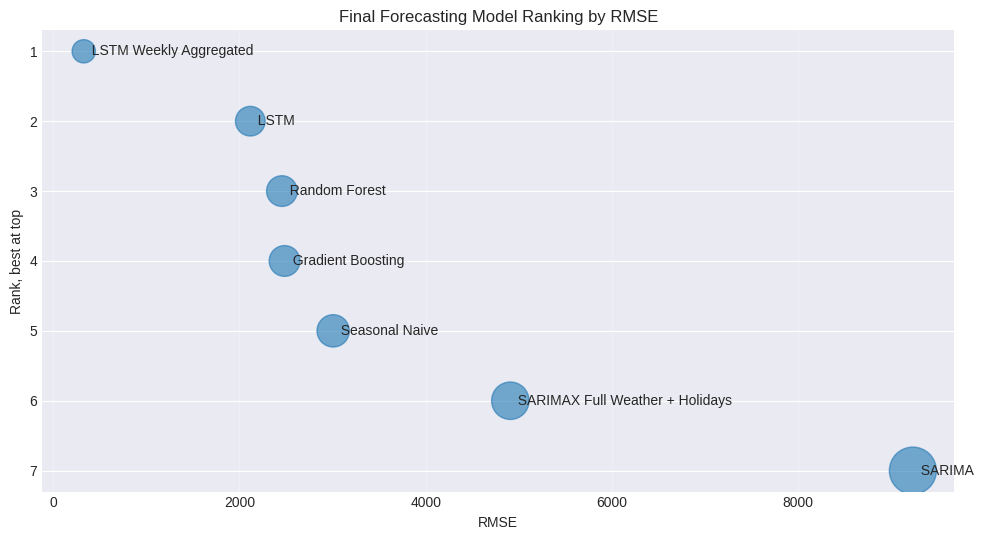

In [194]:
final_rank_v4 = final_table.sort_values("RMSE", ascending=True).reset_index(drop=True)
final_rank_v4["Rank"] = np.arange(1, len(final_rank_v4) + 1)

bubble_sizes_v4 = 250 + 900 * (
    final_rank_v4["RMSE"] / final_rank_v4["RMSE"].max()
)

plt.figure(figsize=(10, 5.5))

plt.scatter(
    final_rank_v4["RMSE"],
    final_rank_v4["Rank"],
    s=bubble_sizes_v4,
    alpha=0.6
)

for _, row in final_rank_v4.iterrows():
    plt.text(
        row["RMSE"],
        row["Rank"],
        f"  {row['Model']}",
        va="center"
    )

plt.gca().invert_yaxis()
plt.title("Final Forecasting Model Ranking by RMSE")
plt.xlabel("RMSE")
plt.ylabel("Rank, best at top")
plt.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()


In [195]:
# Weekly models only

weekly_only_table = final_table[
    final_table["Frequency"].isin(
        [
            "Weekly",
            "Weekly aggregation"
        ]
    )
].copy()

weekly_only_table = (
    weekly_only_table
    .sort_values("RMSE")
    .reset_index(drop=True)
)

weekly_only_table

,Model,Frequency,RMSE,MAE,MAPE
0,LSTM Weekly Aggregated,Weekly aggregation,328.737404,255.009005,0.483220
1,Random Forest,Weekly,2456.336321,1799.712228,3.449297
2,Gradient Boosting,Weekly,2484.774605,1874.092034,3.580260
3,Seasonal Naive,Weekly,3006.760812,2318.520585,4.408920
4,SARIMAX Full Weather + Holidays,Weekly,4908.741760,4012.852841,7.622405
5,SARIMA,Weekly,9230.673409,7924.197337,14.893983


In [196]:
# Best overall model

best_overall = final_table.iloc[0]

print("Best overall model:")
print(best_overall)

Best overall model:
Model        LSTM Weekly Aggregated
Frequency        Weekly aggregation
RMSE                     328.737404
MAE                      255.009005
MAPE                        0.48322
Name: 0, dtype: object


In [197]:
# Best weekly model

best_weekly = weekly_only_table.iloc[0]

print("Best weekly/weekly-aggregated model:")
print(best_weekly)

Best weekly/weekly-aggregated model:
Model        LSTM Weekly Aggregated
Frequency        Weekly aggregation
RMSE                     328.737404
MAE                      255.009005
MAPE                        0.48322
Name: 0, dtype: object


In [198]:
# Collect weekly forecasts for error comparison

weekly_error_table = pd.DataFrame(
    {
        "Actual": test_load,
        "Seasonal Naive": seasonal_naive_forecast,
        "SARIMA": sarima_forecast,
        best_sarimax_name: best_sarimax_forecast
    }
)

# Add feature model forecasts
weekly_error_table["Gradient Boosting"] = boost_forecast
weekly_error_table["Random Forest"] = forest_forecast

# Add weekly aggregated LSTM
weekly_error_table["LSTM Weekly Aggregated"] = weekly_lstm_forecast

weekly_error_table = weekly_error_table.dropna()

weekly_error_table.head()

,Actual,Seasonal Naive,SARIMA,SARIMAX Full Weather + Holidays,Gradient Boosting,Random Forest,LSTM Weekly Aggregated
2018-10-14 00:00:00+00:00,55848.940476,56333.398810,58566.759930,56682.952771,56318.334499,56132.004038,56028.375000
2018-10-21 00:00:00+00:00,55762.125000,56557.309524,58903.203765,57785.362223,57936.206850,57012.779061,55913.082031
2018-10-28 00:00:00+00:00,58684.714286,57687.714286,59398.366855,58777.864664,58360.849647,57345.192538,58532.066406
2018-11-04 00:00:00+00:00,55917.589286,53707.708333,57028.641513,57275.515050,55282.999449,54734.798339,56161.843750
2018-11-11 00:00:00+00:00,58163.470238,59210.357143,61863.932135,59873.114021,58819.588940,58587.514029,58058.023438


In [199]:
# Absolute error table

absolute_errors = weekly_error_table.drop(
    columns=["Actual"]
).apply(
    lambda col: np.abs(weekly_error_table["Actual"] - col)
)

absolute_errors.head()

,Seasonal Naive,SARIMA,SARIMAX Full Weather + Holidays,Gradient Boosting,Random Forest,LSTM Weekly Aggregated
2018-10-14 00:00:00+00:00,484.458333,2717.819454,834.012294,469.394022,283.063562,179.434524
2018-10-21 00:00:00+00:00,795.184524,3141.078765,2023.237223,2174.081850,1250.654061,150.957031
2018-10-28 00:00:00+00:00,997.000000,713.652569,93.150378,323.864639,1339.521748,152.647879
2018-11-04 00:00:00+00:00,2209.880952,1111.052227,1357.925765,634.589837,1182.790947,244.254464
2018-11-11 00:00:00+00:00,1046.886905,3700.461897,1709.643783,656.118702,424.043791,105.446801


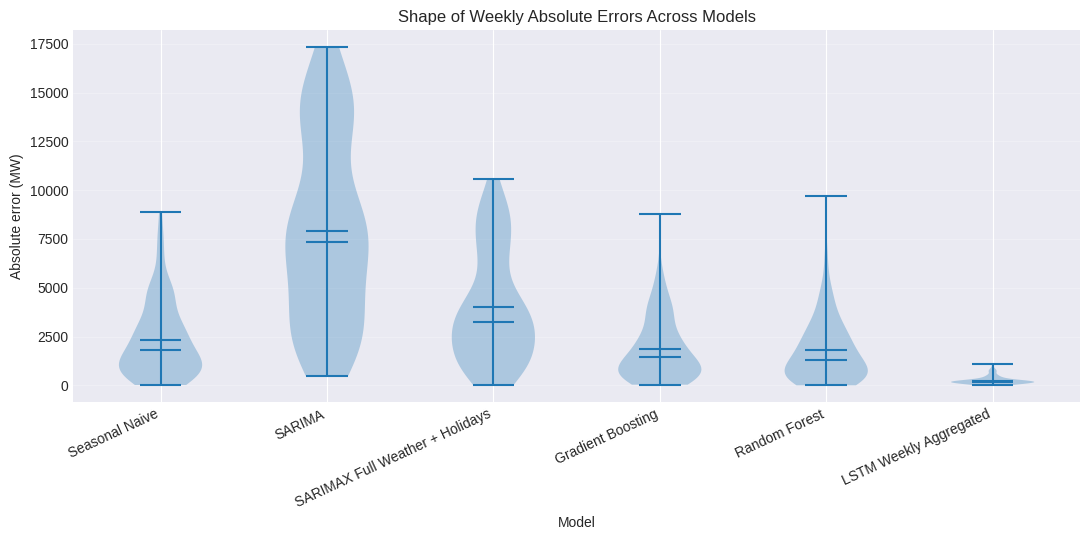

In [200]:
plt.figure(figsize=(11, 5.5))

violin_data_v4 = [
    absolute_errors[col].dropna()
    for col in absolute_errors.columns
]

plt.violinplot(
    violin_data_v4,
    showmeans=True,
    showmedians=True
)

plt.xticks(
    np.arange(1, len(absolute_errors.columns) + 1),
    absolute_errors.columns,
    rotation=25,
    ha="right"
)

plt.title("Shape of Weekly Absolute Errors Across Models")
plt.xlabel("Model")
plt.ylabel("Absolute error (MW)")
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()


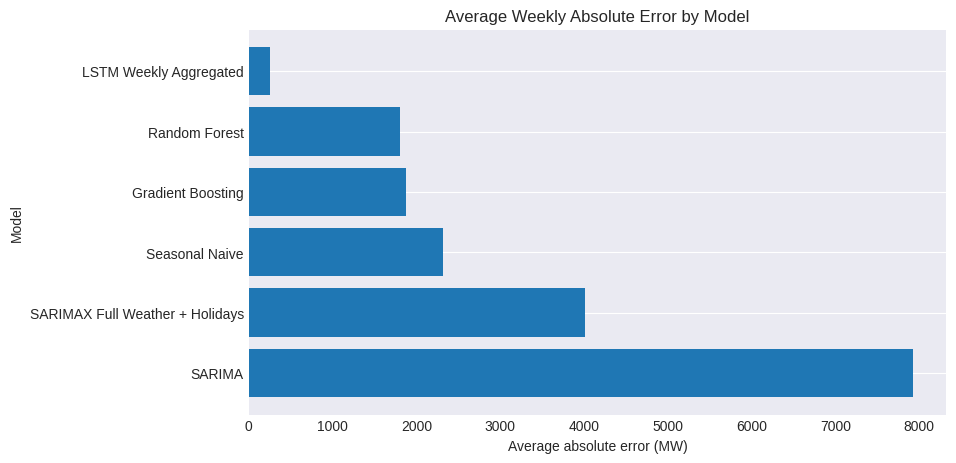

In [201]:
# Average weekly absolute error

average_weekly_error = (
    absolute_errors
    .mean()
    .sort_values()
)

plt.figure(figsize=(9, 5))

plt.barh(
    average_weekly_error.index,
    average_weekly_error.values
)

plt.title("Average Weekly Absolute Error by Model")
plt.xlabel("Average absolute error (MW)")
plt.ylabel("Model")
plt.gca().invert_yaxis()
plt.grid(axis="x")
plt.show()